### Final Project: Detection of Rare Fetal Congenital Heart Diseases (CHD) Using CARDIUM Ultrasound Images and FetalCLIP: A Deep-Learning Model for Rural Coloradans
#### CSCI 5922
#### Spring 2026
#### Meghna Nag and Vanessa Thorsten

# CSCI5922_CARDIUM_Multimodal_Embeddings.ipynb
# Goal:
# 1. Read saved image embeddings and saved tabular embeddings
# 2. Align image-level samples with patient-level tabular embeddings
# 3. Train a multimodal fusion model directly on embeddings
# 4. Compare BCE, Weighted BCE, and Focal Loss
# 5. Evaluate at the patient level using mean pooling

#1. Imports

In [1]:
import os
import re
import json
import random
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
from google.colab import drive
# Meghna's drive path
# drive.mount('/content/gdrive')

# Vanessa's drive path
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Config

In [ ]:
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple
# ------------------------------------------------------------------
# Config class defines the parameters needed to run our multimodal CARDIUM
# ultrasound training approach. We store paths to image and tabular embedding
# files, column names (e.g., image_id, patient_id, label), and naming patterns
# for loading fold-specific datasets used in threefold cross-validation.
# ------------------------------------------------------------------
@dataclass
class Config:
    # Root paths
    # Meghna's root
    # cardium_root:               str  = "/content/gdrive/MyDrive/CARDIUM"
    # Vanessa's root
    cardium_root:                 str = "/content/drive/MyDrive/Colab Notebooks/CARDIUM"
    image_embeddings_dirname:   str  = "CARDIUM_image_embeddings"
    tabular_embeddings_dirname: str  = "CARDIUM_tabular_embeddings"
    # Meghna's output root
    #output_root:                str  = "/content/gdrive/MyDrive/CARDIUM/outputs_multimodal"
    # Vanessa's output root
    output_root:                str  = "/content/drive/MyDrive/Colab Notebooks/CARDIUM/outputs_multimodal"

    # Fold-specific file naming
    image_embedding_pattern:   str = "cardium_fetalclip_embeddings_fold_{fold_idx}.parquet"
    tabular_embedding_pattern: str = "cardium_tabular_embeddings_fold{tab_fold_idx}.parquet"

    # Data columns
    image_id_col:    str = "image_id"
    patient_id_col:  str = "patient_id"
    label_col:       str = "label"
    split_col:       str = "split"
    image_index_col: str = "image_index"
    gest_week_col:   str = "gestational_week_of_imaging"

    # Fold / validation setup
    n_folds:      int   = 3
    val_size:     float = 0.15
    random_state: int   = 42

    # Patient-level image selection
    # Allowing all images per patient rather than limiting the number used.
    # None means use ALL images per patient — no artificial cap
    max_images_per_patient: Optional[int] = None
    selection_strategy:     str           = "all"

    # Model
    # Architecture settings for cross-attention multimodal fusion model,
    # including embedding dimension (256), number of attention heads (4),
    # layers (2), and dropout rate (0.2).
    fusion_model_name:      str           = "cross_attention_patient"
    img_dim:                Optional[int] = None
    tab_dim:                Optional[int] = None
    hidden_dim:             int           = 256
    embed_dim:              int           = 256
    num_heads:              int           = 4
    num_layers:             int           = 2
    dropout:                float         = 0.2
    classifier_hidden_dim:  int           = 128

    # Loss
    # supports weighted binary cross-entropy or focal loss, helping address
    # class imbalance, which we have and is also common in congenital heart
    # disease prediction tasks.
    loss_name:    str            = "weighted_bce"
    pos_weight:   Optional[float] = None
    focal_alpha:  float           = 0.25
    focal_gamma:  float           = 2.0
    use_patient_weighting: bool   = False

    # Training hyperparameters, including batch size (reduced because longer
    # patient image sequences increase memory usage), learning rate (lowered for
    # stability with frozen embeddings), max epochs, and early stopping patience.
    batch_size:         int   = 16      # reduced from 32 because sequences are now longer
    lr:                 float = 1e-4    # reduced from 1e-3, too aggressive for frozen embeddings
    weight_decay:       float = 1e-4
    max_epochs:         int   = 30
    patience:           int   = 6
    decision_threshold: float = 0.5

    # Selects the best model based on PR-AUC instead of recall
    # val_recall will easily gamed by always predicting positive.
    # pr_auc cannot be gamed: it measures the full precision-recall tradeoff
    best_metric: str = "pr_auc"

    # Runtime
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize the configuration as CFG
CFG = Config()
Path(CFG.output_root).mkdir(parents=True, exist_ok=True)
print(CFG)

Config(cardium_root='/content/drive/MyDrive/Colab Notebooks/CARDIUM', image_embeddings_dirname='CARDIUM_image_embeddings', tabular_embeddings_dirname='CARDIUM_tabular_embeddings', output_root='/content/drive/MyDrive/Colab Notebooks/CARDIUM/outputs_multimodal', image_embedding_pattern='cardium_fetalclip_embeddings_fold_{fold_idx}.parquet', tabular_embedding_pattern='cardium_tabular_embeddings_fold{tab_fold_idx}.parquet', image_id_col='image_id', patient_id_col='patient_id', label_col='label', split_col='split', image_index_col='image_index', gest_week_col='gestational_week_of_imaging', n_folds=3, val_size=0.15, random_state=42, max_images_per_patient=None, selection_strategy='all', fusion_model_name='cross_attention_patient', img_dim=None, tab_dim=None, hidden_dim=256, embed_dim=256, num_heads=4, num_layers=2, dropout=0.2, classifier_hidden_dim=128, loss_name='weighted_bce', pos_weight=None, focal_alpha=0.25, focal_gamma=2.0, use_patient_weighting=False, batch_size=16, lr=0.0001, weight

Reproducibility

In [ ]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(CFG.random_state)

Helper functions

In [ ]:
# ------------------------------------------------------------------
# parse_image_id splits an image ID into two parts: a numeric prefix for the image
# count and the patient identifier. Converts the input to a string to ensure
# consistent processing, then uses a regular expression to check whether the
# ID matches the pattern number + underscore + text (for example, "1_12345").
# If the pattern matches, it returns a tuple containing the integer prefix
# (e.g., 1) and the remaining string ID (e.g., "12345"). If the pattern does
# not match, it returns (None, image_id). This prevents the code from crashing.
# ------------------------------------------------------------------
def parse_image_id(image_id: str) -> Tuple[Optional[int], str]:
    """
    Example:
      1_12345 -> (1, '12345')
      2_12345 -> (2, '12345')
    """
    image_id = str(image_id)
    match = re.match(r"^(\d+)_+(.+)$", image_id)
    if match:
        return int(match.group(1)), match.group(2)
    return None, image_id

# compute_binary_metrics provides classification performance metrics from our
# model’s predictions and returns them in a dictionary for easy tracking during
# training and validation. First, it converts predicted probabilities (y_prob)
# into binary class predictions (y_pred) using a decision threshold
# (default = 0.5). Then it calculates precision, recall (sensitivity), F1 score,
# and accuracy by comparing those predicted labels to the true labels (y_true).
# The zero_division=0 setting prevents errors if the model predicts no positives.
# Next, it computes ROC-AUC using the predicted probabilities. This measures
# how well the model separates positive vs. negative classes across all
# thresholds. It also computes PR-AUC (average precision score), which summarizes
# the precision–recall tradeoff. We are using this measure to decide which model
# is best. The function returns a dictionary that includes:
# {
#    "precision": ...,
#    "recall": ...,
#    "f1": ...,
#    "accuracy": ...,
#    "auc": ...,
#    "pr_auc": ...
#}
# We are using this dictionary to track model performance at each epoch.

def compute_binary_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5):
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
    }

    try:
        metrics["auc"] = roc_auc_score(y_true, y_prob)
    except ValueError:
        metrics["auc"] = np.nan

    try:
        metrics["pr_auc"] = average_precision_score(y_true, y_prob)
    except ValueError:
        metrics["pr_auc"] = np.nan

    return metrics

PathManager

In [ ]:
# ------------------------------------------------------------------
# PathManager class organizes and validates file paths for loading image and
# tabular embeddings across cross-validation folds. It keeps all path logic
# in one place so the rest of our training code doesn’t need to manually
# build filenames.
# ------------------------------------------------------------------
class PathManager:
    def __init__(self, config: Config):
        # Stores the configuration
        self.cfg = config

    # Image embeddings directory
    def get_image_embeddings_root(self) -> Path:
        return Path(self.cfg.cardium_root) / self.cfg.image_embeddings_dirname

    # Tabular embeddings directory
    def get_tabular_embeddings_root(self) -> Path:
        return Path(self.cfg.cardium_root) / self.cfg.tabular_embeddings_dirname

    # Builds the image embedding filename for a fold
    def get_image_embedding_path(self, fold_idx: int) -> Path:
        file_name = self.cfg.image_embedding_pattern.format(fold_idx=fold_idx)
        return self.get_image_embeddings_root() / file_name

    # Builds the tabular embedding filename for a fold
    def get_tabular_embedding_path(self, fold_idx: int) -> Path:
        # image folds are 1,2,3 but your tab files appear 0,1,2
        tab_fold_idx = fold_idx - 1
        file_name = self.cfg.tabular_embedding_pattern.format(tab_fold_idx=tab_fold_idx)
        return self.get_tabular_embeddings_root() / file_name

    # Verifies that required files exist
    # prints the expected image embedding path and whether the file exists
    # prints the expected tabular embedding path and whether the file exists
    # raises an error if either file is missing
    def validate_paths(self, fold_idx: int):
        img_path = self.get_image_embedding_path(fold_idx)
        tab_path = self.get_tabular_embedding_path(fold_idx)

        print("Image path:", img_path)
        print("Exists?", img_path.exists())
        print("Tabular path:", tab_path)
        print("Exists?", tab_path.exists())

        if not img_path.exists():
            raise FileNotFoundError(f"Missing image embedding file: {img_path}")
        if not tab_path.exists():
            raise FileNotFoundError(f"Missing tabular embedding file: {tab_path}")

EmbeddingLoader

In [ ]:
# ------------------------------------------------------------------
# EmbeddingLoader class loads and standardizes image and tabular embedding files
# for each cross-validation fold. This prepares the files for that they can
# be merged later in our multimodal model. It ensures the required columns exist
# and automatically reconstructs missing identifiers when needed.
# ------------------------------------------------------------------
class EmbeddingLoader:
    def __init__(self, config: Config, path_manager: PathManager):
        self.cfg = config
        self.path_manager = path_manager

    def load_image_embeddings(self, fold_idx: int) -> pd.DataFrame:
        path = self.path_manager.get_image_embedding_path(fold_idx)
        df = pd.read_parquet(path)

        print("Loaded image embeddings:", df.shape)
        print("Image columns:", df.columns.tolist())

        if self.cfg.image_id_col not in df.columns:
            raise ValueError(
                f"Expected column '{self.cfg.image_id_col}' in image embeddings, "
                f"but got: {df.columns.tolist()}"
            )

        if self.cfg.patient_id_col not in df.columns:
            parsed = df[self.cfg.image_id_col].apply(parse_image_id)
            df[self.cfg.image_index_col] = [x[0] for x in parsed]
            df[self.cfg.patient_id_col] = [x[1] for x in parsed]
        else:
            if self.cfg.image_index_col not in df.columns:
                parsed = df[self.cfg.image_id_col].apply(parse_image_id)
                df[self.cfg.image_index_col] = [x[0] for x in parsed]

        return df

    def load_tabular_embeddings(self, fold_idx: int) -> pd.DataFrame:
        path = self.path_manager.get_tabular_embedding_path(fold_idx)
        df = pd.read_parquet(path)

        print("Loaded tabular embeddings:", df.shape)
        print("Tabular columns:", df.columns.tolist())

        if self.cfg.patient_id_col not in df.columns:
            raise ValueError(
                f"Expected column '{self.cfg.patient_id_col}' in tabular embeddings, "
                f"but got: {df.columns.tolist()}"
            )

        return df

Column inference helper functions

In [ ]:
# ------------------------------------------------------------------
# infer_embedding_columns returns all columns that are not in a specified
# exclusion list. Once metadata columns are removed, the remaining columns
# are embedding features.
# ------------------------------------------------------------------
def infer_embedding_columns(df: pd.DataFrame, exclude_cols: List[str]) -> List[str]:
    return [c for c in df.columns if c not in exclude_cols]


# infer_image_tabular_cols identifies numeric embedding columns separately for
# image embeddings and tabular embeddings by doing the following:
# 1) Define metadata columns to ignore (img_exclude and tab_exclude)
# 2) Keep only numeric feature columns (img_cols and tab_cols)
# 3) Return embedding column lists (img_cols, tab_cols)
def infer_image_tabular_cols(img_df: pd.DataFrame, tab_df: pd.DataFrame, cfg: Config):
    img_exclude = {
        cfg.image_id_col,
        cfg.patient_id_col,
        cfg.image_index_col,
        cfg.label_col,
        cfg.split_col,
        cfg.gest_week_col,
        "image_path",
        "filename",
        "class_name",
        "fold",
        "ok"
    }

    tab_exclude = {
        cfg.patient_id_col,
        cfg.label_col,
        cfg.split_col
    }

    img_cols = [
        c for c in img_df.columns
        if c not in img_exclude and pd.api.types.is_numeric_dtype(img_df[c])
    ]

    tab_cols = [
        c for c in tab_df.columns
        if c not in tab_exclude and pd.api.types.is_numeric_dtype(tab_df[c])
    ]

    return img_cols, tab_cols

ImageSelector

In [ ]:
# ------------------------------------------------------------------
# CARDIUM contains more images for the CHD cases than for the non-CHD patients.
# As such, we discussed whether we may need to limit the number of images per
# patient. If we do that, the ImageSelector class will allow us to control how
# many image embeddings to keep per patient and which images to keep so that
# patients with many scans do not overwhelm the multimodal model.
# Its main job is to apply a consistent patient-level image sampling strategy
# before training.
# The helper _evenly_spaced_indices(n, k) picks k indices spread across n
# available images, which avoids selecting only early or only late images from a
# patient’s sequence. The _select_evenly_spaced() method first sorts a patient’s
# images by image_index, then keeps a subset that is distributed across that
# ordered sequence. The _select_gestational_spread() method is a more clinically
# informed option: it tries to spread selected images across gestational weeks,
# using valid gestational ages first and filling any remaining slots with images
# whose gestational age is missing. If gestational age is unavailable, it falls
# back to the evenly spaced strategy.
# ------------------------------------------------------------------
class ImageSelector:
    def __init__(self, config: Config):
        self.cfg = config

    def _evenly_spaced_indices(self, n: int, k: int) -> List[int]:
        if n <= k:
            return list(range(n))
        raw = np.linspace(0, n - 1, num=k)
        idx = np.round(raw).astype(int).tolist()
        idx = sorted(list(dict.fromkeys(idx)))
        while len(idx) < k:
            for i in range(n):
                if i not in idx:
                    idx.append(i)
                if len(idx) == k:
                    break
        return sorted(idx[:k])

    def _select_evenly_spaced(self, df_patient: pd.DataFrame) -> pd.DataFrame:
        df_patient = df_patient.sort_values(
            by=self.cfg.image_index_col
        ).reset_index(drop=True)
        idx = self._evenly_spaced_indices(
            len(df_patient), self.cfg.max_images_per_patient
        )
        return df_patient.iloc[idx].copy()

    def _select_gestational_spread(self, df_patient: pd.DataFrame) -> pd.DataFrame:
        df_patient = df_patient.copy()
        if self.cfg.gest_week_col not in df_patient.columns:
            return self._select_evenly_spaced(df_patient)
        df_patient["gest_week_clean"] = pd.to_numeric(
            df_patient[self.cfg.gest_week_col], errors="coerce"
        )
        df_patient.loc[
            df_patient["gest_week_clean"] < 0, "gest_week_clean"
        ] = np.nan
        valid_df = (
            df_patient[df_patient["gest_week_clean"].notna()]
            .sort_values("gest_week_clean")
            .reset_index(drop=True)
        )
        unknown_df = (
            df_patient[df_patient["gest_week_clean"].isna()]
            .sort_values(self.cfg.image_index_col)
            .reset_index(drop=True)
        )
        selected_parts = []
        if len(valid_df) >= self.cfg.max_images_per_patient:
            idx = self._evenly_spaced_indices(
                len(valid_df), self.cfg.max_images_per_patient
            )
            selected_parts.append(valid_df.iloc[idx].copy())
        else:
            if len(valid_df) > 0:
                selected_parts.append(valid_df.copy())
            remaining = self.cfg.max_images_per_patient - len(valid_df)
            if remaining > 0 and len(unknown_df) > 0:
                idx = self._evenly_spaced_indices(len(unknown_df), remaining)
                selected_parts.append(unknown_df.iloc[idx].copy())
        if len(selected_parts) == 0:
            return self._select_evenly_spaced(df_patient)
        out = pd.concat(selected_parts, axis=0).drop_duplicates()
        out = out.sort_values(
            by=self.cfg.image_index_col
        ).reset_index(drop=True)
        if len(out) > self.cfg.max_images_per_patient:
            out = out.iloc[:self.cfg.max_images_per_patient].copy()
        return out

    # select_image_rows(), applies the above logic for each patient.
    # The code is currently set so that if max_images_per_patient is None or the
    # strategy is "all", it returns all images for every patient, meaning no
    # artificial cap is applied. Otherwise, it groups rows by patient_id and either
    # keeps all images for patients already under the limit or downsamples them
    # according to the chosen strategy ("evenly_spaced" or "gestational_spread").

    def select_image_rows(self, df: pd.DataFrame) -> pd.DataFrame:
        # if max_images is None or strategy is "all", always return everything
        if (
            self.cfg.max_images_per_patient is None
            or self.cfg.selection_strategy == "all"
        ):
            return df.copy()

        selected = []
        for _, df_patient in df.groupby(self.cfg.patient_id_col):
            if len(df_patient) <= self.cfg.max_images_per_patient:
                selected.append(df_patient.copy())
            elif self.cfg.selection_strategy == "evenly_spaced":
                selected.append(self._select_evenly_spaced(df_patient))
            elif self.cfg.selection_strategy == "gestational_spread":
                selected.append(self._select_gestational_spread(df_patient))
            else:
                raise ValueError(
                    f"Unknown selection strategy: {self.cfg.selection_strategy}"
                )
        return pd.concat(selected, axis=0).reset_index(drop=True)

MultimodalDatasetBuilder

In [ ]:
# ------------------------------------------------------------------
# MultimodalDatasetBuilder class builds the fold-specific multimodal dataframe
# that combines image embeddings and tabular embeddings. It splits it into train,
# validation, and test sets at the patient level.
# ------------------------------------------------------------------
class MultimodalDatasetBuilder:
    def __init__(self, config: Config, path_manager, embedding_loader, image_selector):
        self.cfg = config
        self.path_manager = path_manager
        self.embedding_loader = embedding_loader
        self.image_selector = image_selector

    # _prepare_image_df() method checks that the image dataframe contains the
    # required columns, especially image_id, split, and label. If patient_id or
    # image_index are missing, it reconstructs them from image_id using
    # parse_image_id.
    def _prepare_image_df(self, img_df: pd.DataFrame) -> pd.DataFrame:
        if self.cfg.image_id_col not in img_df.columns:
            raise ValueError(f"Missing required image id column: {self.cfg.image_id_col}")

        if self.cfg.patient_id_col not in img_df.columns:
            parsed = img_df[self.cfg.image_id_col].apply(parse_image_id)
            img_df[self.cfg.image_index_col] = [x[0] for x in parsed]
            img_df[self.cfg.patient_id_col] = [x[1] for x in parsed]
        else:
            if self.cfg.image_index_col not in img_df.columns:
                parsed = img_df[self.cfg.image_id_col].apply(parse_image_id)
                img_df[self.cfg.image_index_col] = [x[0] for x in parsed]

        if self.cfg.split_col not in img_df.columns:
            raise ValueError(
                f"Expected '{self.cfg.split_col}' in image embeddings, but it was not found. "
                f"Available columns: {img_df.columns.tolist()}"
            )

        if self.cfg.label_col not in img_df.columns:
            raise ValueError(
                f"Expected '{self.cfg.label_col}' in image embeddings, but it was not found. "
                f"Available columns: {img_df.columns.tolist()}"
            )

        return img_df

    # build_fold_image_row_dataframe() method first validates that the fold’s
    # image and tabular embedding files exist, then loads both files and infers
    # which columns are actual embedding features. It keeps the patient ID and
    # tabular embedding columns, and optionally keeps the label from the tabular
    # file. Then it merges the tabular embeddings onto the image dataframe by
    # patient_id, so each image row ends up with both its image embedding and
    # that patient’s tabular embedding. It also updates cfg.img_dim and
    # cfg.tab_dim so the model later knows the dimensionality of each modality.
    def build_fold_image_row_dataframe(self, fold_idx: int):
        self.path_manager.validate_paths(fold_idx)

        img_df = self.embedding_loader.load_image_embeddings(fold_idx)
        tab_df = self.embedding_loader.load_tabular_embeddings(fold_idx)

        img_df = self._prepare_image_df(img_df)
        img_cols, tab_cols = infer_image_tabular_cols(img_df, tab_df, self.cfg)

        tab_keep_cols = [self.cfg.patient_id_col] + tab_cols
        if self.cfg.label_col in tab_df.columns and self.cfg.label_col not in tab_keep_cols:
            tab_keep_cols.append(self.cfg.label_col)

        merged = img_df.merge(
            tab_df[tab_keep_cols].drop_duplicates(subset=[self.cfg.patient_id_col]),
            on=self.cfg.patient_id_col,
            how="inner",
            suffixes=("", "_tab")
        )

        self.cfg.img_dim = len(img_cols)
        self.cfg.tab_dim = len(tab_cols)

        return merged.reset_index(drop=True), img_cols, tab_cols

    # split_image_row_dataframe() method separates the merged dataframe into the
    # original train and test partitions using the split column. From the
    # training portion only, it creates a patient-level train/validation split
    # using train_test_split with stratification by label. This approach helps
    # preserve the class balance between train and validation sets. It then maps
    # those patient IDs back to image rows, producing train_df, val_df, and
    # test_df without leaking images from the same patient across splits.
    def split_image_row_dataframe(self, df: pd.DataFrame):
        if "train" not in df[self.cfg.split_col].unique():
            raise ValueError("Expected 'train' in split column.")
        if "test" not in df[self.cfg.split_col].unique():
            raise ValueError("Expected 'test' in split column.")

        train_full_df = df[df[self.cfg.split_col] == "train"].copy()
        test_df = df[df[self.cfg.split_col] == "test"].copy()

        patient_df = train_full_df[[self.cfg.patient_id_col, self.cfg.label_col]].drop_duplicates()

        train_patients, val_patients = train_test_split(
            patient_df,
            test_size=self.cfg.val_size,
            stratify=patient_df[self.cfg.label_col],
            random_state=self.cfg.random_state
        )

        train_patient_ids = set(train_patients[self.cfg.patient_id_col])
        val_patient_ids = set(val_patients[self.cfg.patient_id_col])

        train_df = train_full_df[train_full_df[self.cfg.patient_id_col].isin(train_patient_ids)].copy()
        val_df = train_full_df[train_full_df[self.cfg.patient_id_col].isin(val_patient_ids)].copy()

        return train_df, val_df, test_df

PatientSequenceBuilder

In [ ]:
# ------------------------------------------------------------------
# PatientSequenceBuilder class converts the merged image-row-level dataframe into
# a patient-level dataframe. This combined dataframe is used in the multimodal
# training. It takes all rows belonging to a given patient and bundles that
# patient’s multiple image embeddings together into a single sequence and
# attaches the patient’s tabular embedding and label.
# ------------------------------------------------------------------
class PatientSequenceBuilder:
    def __init__(self, config: Config, image_selector: ImageSelector):
        self.cfg = config
        self.image_selector = image_selector

    # build_patient_level_dataframe() method loops through the data grouped by
    # patient_id, so each iteration handles one patient at a time. For each
    # patient, it applies ImageSelector to decide which image rows to keep.
    # Any per-patient image subsampling strategy is enforced here (if we decide)
    # we need this). It then pulls out the patient’s label and split, assumes
    # the tabular embedding is the same across that patient’s rows, and stores
    # it once as tab_vector. At the same time, it collects all selected image
    # embedding rows into a list called image_vectors and keeps the corresponding
    # image_ids for traceability. Finally, it creates one dictionary per patient
    # containing the patient ID, label, split, tabular vector, list of image
    # vectors, and the number of images used, then returns a new dataframe.
    def build_patient_level_dataframe(
        self,
        image_row_df: pd.DataFrame,
        img_cols: List[str],
        tab_cols: List[str]
    ) -> pd.DataFrame:
        rows = []

        for patient_id, df_patient in image_row_df.groupby(self.cfg.patient_id_col):
            df_patient = df_patient.copy().reset_index(drop=True)
            df_patient_selected = self.image_selector.select_image_rows(df_patient)

            label = int(df_patient_selected[self.cfg.label_col].iloc[0])
            split = df_patient_selected[self.cfg.split_col].iloc[0]

            tab_vector = df_patient_selected.iloc[0][tab_cols].astype(np.float32).values
            image_vectors = df_patient_selected[img_cols].astype(np.float32).values.tolist()
            image_ids = df_patient_selected[self.cfg.image_id_col].astype(str).tolist()

            patient_row = {
                self.cfg.patient_id_col: patient_id,
                self.cfg.label_col: label,
                self.cfg.split_col: split,
                "image_vectors": image_vectors,
                "image_ids": image_ids,
                "num_images_used": len(image_vectors),
                "tab_vector": tab_vector
            }

            rows.append(patient_row)

        return pd.DataFrame(rows)

Dataset + DataLoaderFactory

In [ ]:
# ------------------------------------------------------------------
# PatientSequenceDataset
# Changes: max_k is computed from the actual dataset at __init__ time
#          so it never crashes when max_images_per_patient is None
#
# PatientSequenceDataset stores the patient-level dataframe and computes
# self.max_k as the largest number of images used by any patient in that dataset,
# rather than relying on cfg.max_images_per_patient, which might be None.
# ------------------------------------------------------------------
class PatientSequenceDataset(Dataset):
    def __init__(self, df: pd.DataFrame, config: Config):
        self.df  = df.reset_index(drop=True)
        self.cfg = config

        # derive true max sequence length from this dataset's data,
        # not from cfg.max_images_per_patient which may be None
        self.max_k = int(
            self.df["num_images_used"].max()
        ) if len(self.df) > 0 else 1
        print(f"  PatientSequenceDataset: {len(self.df)} patients, "
              f"max_images_used={self.max_k}")

    def __len__(self):
        return len(self.df)

    # _pad_image_sequence() method creates a fixed-size image sequence array of
    # shape (max_k, img_dim) filled with zeros, then inserts the patient’s actual
    # image embeddings at the front and marks the remaining positions as padding
    # with a boolean key_padding_mask.
    def _pad_image_sequence(self, image_vectors: List[List[float]]):
        # use self.max_k (from data) instead of cfg.max_images_per_patient
        img_dim = self.cfg.img_dim
        seq = np.zeros((self.max_k, img_dim), dtype=np.float32)
        key_padding_mask = np.ones((self.max_k,), dtype=bool)  # True = padding

        k = min(len(image_vectors), self.max_k)
        if k > 0:
            seq[:k] = np.array(image_vectors[:k], dtype=np.float32)
            key_padding_mask[:k] = False
        return seq, key_padding_mask

    # __getitem__ returns a dictionary containing the padded image sequence, the
    # padding mask, the tabular embedding, the label, the patient ID, and the
    # number of images used, all in tensor-ready form.
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_seq, img_key_padding_mask = self._pad_image_sequence(
            row["image_vectors"]
        )
        tab_vector = np.array(row["tab_vector"], dtype=np.float32)
        label      = np.float32(row[self.cfg.label_col])

        return {
            "img_seq":              torch.tensor(img_seq,              dtype=torch.float32),
            "img_key_padding_mask": torch.tensor(img_key_padding_mask, dtype=torch.bool),
            "tab_emb":              torch.tensor(tab_vector,           dtype=torch.float32),
            "label":                torch.tensor(label,                dtype=torch.float32),
            "patient_id":           str(row[self.cfg.patient_id_col]),
            "num_images_used":      int(row["num_images_used"])
        }


# ------------------------------------------------------------------
# PatientSequenceDataLoaderFactory
# Changes: computes global max_images across ALL three splits,
#          stores it back to cfg so CrossAttentionPatientModel's
#          padding is consistent across train / val / test batches
# ------------------------------------------------------------------
class PatientSequenceDataLoaderFactory:
    def __init__(self, config: Config):
        self.cfg = config

    def build(
        self,
        train_df: pd.DataFrame,
        val_df:   pd.DataFrame,
        test_df:  pd.DataFrame
    ):
        # compute the true global max across all splits before
        # building any Dataset so every dataset pads to the same length
        global_max_k = int(
            pd.concat([train_df, val_df, test_df])["num_images_used"].max()
        )
        print(f"Global max images per patient across splits: {global_max_k}")

        # Write back into cfg so it is available to models / datasets
        self.cfg.max_images_per_patient = global_max_k

        train_ds = PatientSequenceDataset(train_df, self.cfg)
        val_ds   = PatientSequenceDataset(val_df,   self.cfg)
        test_ds  = PatientSequenceDataset(test_df,  self.cfg)

        train_loader = DataLoader(
            train_ds, batch_size=self.cfg.batch_size, shuffle=True
        )
        val_loader   = DataLoader(
            val_ds, batch_size=self.cfg.batch_size, shuffle=False
        )
        test_loader  = DataLoader(
            test_ds, batch_size=self.cfg.batch_size, shuffle=False
        )
        return train_loader, val_loader, test_loader


Models

In [ ]:
# ------------------------------------------------------------------
# MLPPatientModel class defines a baseline multimodal neural network that
# combines image embeddings and tabular embeddings at the patient level using
# simple pooling plus a multilayer perceptron (MLP).
# ------------------------------------------------------------------

class MLPPatientModel(nn.Module):
    def __init__(self, img_dim: int, tab_dim: int, hidden_dim: int, dropout: float):
        super().__init__()

        # Projection layer - pooled image embeddings → hidden feature space
        # The projection uses a linear layer, layer normalization and ReLU
        # activation.
        self.img_proj = nn.Sequential(
            nn.Linear(img_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )

        # Projection layer - tabular embeddings → hidden feature space
        # The projection uses a linear layer, layer normalization and ReLU
        # activation.
        self.tab_proj = nn.Sequential(
            nn.Linear(tab_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )

        # The classifier block takes the concatenated image + tabular features and
        # passes them through: Linear(hidden_dim × 2 → hidden_dim), ReLU, Dropout,
        # Linear(hidden_dim → hidden_dim/2), ReLU, Dropout,
        # Linear(hidden_dim/2 → 1). The output is a single logit representing
        # predicted CHD probability later when sigmoid is applied.
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )

    # The forward() function removes padded images before pooling with
    # valid_mask = (~img_key_padding_mask). This ensures padded image slots
    # are ignored. Then it averages the patient’s image embeddings with
    # pooled_img = weighted mean of valid images. Multiple ultrasound images
    # become one patient-level image feature vector. Then it projects both
    # modalities with img_feat = self.img_proj() and
    # tab_feat = self.tab_proj(). The modalities are fused here:
    # fused = concat(img_feat, tab_feat). Then the model classifies the
    # patient with logits = self.classifier(fused) and the logits are
    # returned.
    def forward(self, img_seq, img_key_padding_mask, tab_emb):
        valid_mask = (~img_key_padding_mask).float().unsqueeze(-1)
        pooled_img = (img_seq * valid_mask).sum(dim=1) / valid_mask.sum(dim=1).clamp(min=1.0)

        img_feat = self.img_proj(pooled_img)
        tab_feat = self.tab_proj(tab_emb)

        fused = torch.cat([img_feat, tab_feat], dim=1)
        logits = self.classifier(fused).squeeze(1)
        return logits

# CrossAttentionPatientModel class defines our multimodal fusion model for
# patient-level prediction. It takes a sequence of image embeddings for each
# patient plus a single tabular embedding, lets the two modalities interact
# through cross-attention, and then outputs one logit for binary classification.
class CrossAttentionPatientModel(nn.Module):
    def __init__(
        self,
        img_dim: int,
        tab_dim: int,
        embed_dim: int,
        num_heads: int,
        num_layers: int,
        dropout: float,
        classifier_hidden_dim: int
    ):
        super().__init__()
        # Projects both modalities into the same embed_dim space: each image
        # embedding becomes an image token, and the tabular embedding becomes a
        # single tab token.
        self.img_proj = nn.Sequential(
            nn.Linear(img_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU()
        )

        self.tab_proj = nn.Sequential(
            nn.Linear(tab_dim, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.ReLU()
        )

        # Passes the image tokens through a Transformer encoder, which allows the
        # different ultrasound images for a patient to interact with each other
        # before fusion.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 2,
            dropout=dropout,
            batch_first=True
        )
        self.image_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # tab-to-image attention allows the tabular token to attend to the full
        # image sequence, producing a refined tabular representation informed by
        # the images.
        self.tab_to_img_attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # image-to-tab attention allows each image token to attend back to the
        # refined tabular token, producing image representations that now
        # incorporate tabular context.
        self.img_to_tab_attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # Layer normalization is applied after both attention steps to stabilize training.
        self.img_norm = nn.LayerNorm(embed_dim)
        self.tab_norm = nn.LayerNorm(embed_dim)

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, classifier_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(classifier_hidden_dim, classifier_hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(classifier_hidden_dim // 2, 1)
        )

    # Once cross-modal interaction is complete, the model summarizes the image
    # sequence with a masked mean pool, which ignores padded image positions
    # using img_key_padding_mask, while the refined tab token is kept as the
    # tabular summary. These pooled image and tabular representations are
    # concatenated and passed through an MLP classifier to produce a single
    # output logit per patient.
    def masked_mean_pool(self, x: torch.Tensor, key_padding_mask: torch.Tensor):
        valid_mask = (~key_padding_mask).float().unsqueeze(-1)
        x_sum = (x * valid_mask).sum(dim=1)
        denom = valid_mask.sum(dim=1).clamp(min=1.0)
        return x_sum / denom

    def forward(self, img_seq, img_key_padding_mask, tab_emb):
        img_tokens = self.img_proj(img_seq)                      # [B, K, E]
        tab_token = self.tab_proj(tab_emb).unsqueeze(1)         # [B, 1, E]

        img_tokens = self.image_encoder(
            img_tokens,
            src_key_padding_mask=img_key_padding_mask
        )

        tab_refined, _ = self.tab_to_img_attn(
            query=tab_token,
            key=img_tokens,
            value=img_tokens,
            key_padding_mask=img_key_padding_mask
        )
        tab_refined = self.tab_norm(tab_refined)

        img_refined, _ = self.img_to_tab_attn(
            query=img_tokens,
            key=tab_refined,
            value=tab_refined
        )
        img_refined = self.img_norm(img_refined)

        pooled_img = self.masked_mean_pool(img_refined, img_key_padding_mask)
        pooled_tab = tab_refined.squeeze(1)

        fused = torch.cat([pooled_img, pooled_tab], dim=1)
        logits = self.classifier(fused).squeeze(1)
        return logits

# This class allows for some flexibility in choosing which architecture to
# instantiate before training starts - either the first one above
# (MLPPatientModel), which is simplier or the second modeling approach
# (CrossAttentionPatientModel)
class ModelFactory:
    def __init__(self, config: Config):
        self.cfg = config

    def build(self):
        if self.cfg.fusion_model_name == "mlp_patient":
            return MLPPatientModel(
                img_dim=self.cfg.img_dim,
                tab_dim=self.cfg.tab_dim,
                hidden_dim=self.cfg.hidden_dim,
                dropout=self.cfg.dropout
            )

        if self.cfg.fusion_model_name == "cross_attention_patient":
            return CrossAttentionPatientModel(
                img_dim=self.cfg.img_dim,
                tab_dim=self.cfg.tab_dim,
                embed_dim=self.cfg.embed_dim,
                num_heads=self.cfg.num_heads,
                num_layers=self.cfg.num_layers,
                dropout=self.cfg.dropout,
                classifier_hidden_dim=self.cfg.classifier_hidden_dim
            )

        raise ValueError(f"Unsupported fusion model: {self.cfg.fusion_model_name}")

LossManager

In [ ]:
# ------------------------------------------------------------------
# Study Experiment: Loss Functions
# This code block defines the loss functions used during training and a manager
# class that selects the appropriate one based on our configuration. It controls
# how prediction errors are penalized, especially important for class-imbalanced
# problems like congenital heart disease detection. For weighted BCE we have the
# extra hyperparameter of pos_weight. For focal loss we have the additional
# hyperparameters for alpha and gamma
# ------------------------------------------------------------------

# This computes standard binary cross-entropy (BCE) directly from logits (no
# sigmoid required beforehand). It returns per-sample losses instead of
# immediately averaging them by specifying reduction="none"
class BCELossWrapper(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        return F.binary_cross_entropy_with_logits(
            input=logits,
            target=targets,
            reduction="none"
        )

# WeightedBCELossWrapper increases the penalty for false negatives by assigning
# extra weight to the positive class: e.g. pos_weight > 1. This prevents the
# model from learning to predict non-CHD too often. Weighted BCE fixes that by
# making mistakes on positives more costly.
class WeightedBCELossWrapper(nn.Module):
    def __init__(self, pos_weight: float):
        super().__init__()
        self.pos_weight = pos_weight

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        pos_weight_tensor = torch.tensor(
            self.pos_weight,
            dtype=logits.dtype,
            device=logits.device
        )

        return F.binary_cross_entropy_with_logits(
            input=logits,
            target=targets,
            reduction="none",
            pos_weight=pos_weight_tensor
        )

# FocalLossWrapper modifies BCE using:
# focal_loss = alpha_t * ((1 − pt)^gamma) * BCE
# Where: alpha balances class importance and gamma downweights easy examples
# hard examples contribute more gradient signal
class FocalLossWrapper(nn.Module):
    def __init__(self, alpha: float = 0.25, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce_loss = F.binary_cross_entropy_with_logits(
            input=logits,
            target=targets,
            reduction="none"
        )

        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)

        focal_loss = alpha_t * ((1.0 - pt) ** self.gamma) * bce_loss
        return focal_loss


class LossManager:
    def __init__(self, config: Config, pos_weight: Optional[float] = None):
        self.cfg = config
        self.pos_weight = pos_weight
        self.loss_fn = self._build_loss_function()

    def _build_loss_function(self):
        if self.cfg.loss_name == "bce":
            return BCELossWrapper()

        if self.cfg.loss_name == "weighted_bce":
            if self.pos_weight is None:
                raise ValueError("pos_weight must be provided when loss_name='weighted_bce'.")
            return WeightedBCELossWrapper(pos_weight=self.pos_weight)

        if self.cfg.loss_name == "focal":
            return FocalLossWrapper(
                alpha=self.cfg.focal_alpha,
                gamma=self.cfg.focal_gamma
            )

        raise ValueError(f"Unsupported loss_name: {self.cfg.loss_name}")

    # take the average of the per sample loss
    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        per_sample_loss = self.loss_fn(logits, targets)
        return per_sample_loss.mean()

PatientLevelEvaluator

Trainer

In [ ]:
# ------------------------------------------------------------------
# Because we are trying to minimize false negatives without overinflating false
# positives, we are using PR-AUC for the best model.
# best checkpoint = highest validation PR-AUC
# early stopping monitors PR-AUC
# saved model metadata records PR-AUC
# printed improvement message references PR-AUC
# ------------------------------------------------------------------
class Trainer:
    def __init__(
        self,
        config: Config,
        model,
        loss_manager,
        optimizer,
        train_loader,
        val_loader,
        test_loader,
        fold_idx: int,
        checkpoint_dir: str
    ):
        self.cfg = config
        self.model = model.to(self.cfg.device)
        self.loss_manager = loss_manager
        self.optimizer = optimizer

        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.fold_idx = fold_idx

        self.checkpoint_dir = Path(checkpoint_dir)
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)

        self.best_metric_name = self.cfg.best_metric
        self.best_metric_value = -np.inf
        self.best_epoch = None
        self.best_state = None
        self.best_checkpoint_path = self.checkpoint_dir / f"best_model_fold_{self.fold_idx}.pt"
        self.best_val_metrics = None
        self.best_val_y_true = None
        self.best_val_y_prob = None

        self.history = []

    def _move_batch(self, batch):
        img_seq = batch["img_seq"].to(self.cfg.device)
        img_key_padding_mask = batch["img_key_padding_mask"].to(self.cfg.device)
        tab_emb = batch["tab_emb"].to(self.cfg.device)
        labels = batch["label"].to(self.cfg.device)
        patient_ids = batch["patient_id"]
        return img_seq, img_key_padding_mask, tab_emb, labels, patient_ids



    def train_one_epoch(self):
        self.model.train()
        total_loss = 0.0
        total_batches = 0

        for batch in self.train_loader:
            img_seq, img_key_padding_mask, tab_emb, labels, _ = self._move_batch(batch)

            self.optimizer.zero_grad()

            logits = self.model(
                img_seq=img_seq,
                img_key_padding_mask=img_key_padding_mask,
                tab_emb=tab_emb
            )

            loss = self.loss_manager(logits, labels)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            total_batches += 1

        return total_loss / max(total_batches, 1)

    @torch.no_grad()
    def evaluate_loader(self, loader):
        self.model.eval()

        total_loss = 0.0
        total_batches = 0

        all_probs = []
        all_labels = []

        for batch in loader:
            img_seq, img_key_padding_mask, tab_emb, labels, _ = self._move_batch(batch)

            logits = self.model(
                img_seq=img_seq,
                img_key_padding_mask=img_key_padding_mask,
                tab_emb=tab_emb
            )

            loss = self.loss_manager(logits, labels)

            probs = torch.sigmoid(logits).cpu().numpy()
            labels_np = labels.cpu().numpy()

            total_loss += loss.item()
            total_batches += 1

            all_probs.extend(probs.tolist())
            all_labels.extend(labels_np.tolist())

        avg_loss = total_loss / max(total_batches, 1)

        metrics = compute_binary_metrics(
            y_true=np.array(all_labels),
            y_prob=np.array(all_probs),
            threshold=self.cfg.decision_threshold
        )
        metrics["loss"] = avg_loss

        return metrics, np.array(all_labels), np.array(all_probs)

    def _save_best_checkpoint(self):
        torch.save(
            {
                "fold": self.fold_idx,
                "best_epoch": self.best_epoch,
                "best_metric_name": self.best_metric_name,
                "best_metric_value": self.best_metric_value,
                "best_val_metrics": self.best_val_metrics,
                "model_state_dict": self.best_state,
                "config": asdict(self.cfg),
            },
            self.best_checkpoint_path
        )

    # Training loop per epoch
    # Each epoch: trains model, train_one_epoch(), evaluates validation set,
    # evaluate_loader(val_loader), logs metrics: val_loss, val_recall, val_f1,
    # val_pr_auc, compares validation metric to best so far:
    # val_metrics[self.best_metric_name], saves checkpoint if improved
    def fit(self):
        patience_counter = 0

        for epoch in range(1, self.cfg.max_epochs + 1):
            train_loss = self.train_one_epoch()
            val_metrics, val_y_true, val_y_prob = self.evaluate_loader(self.val_loader)

            row = {
                "fold": self.fold_idx,
                "epoch": epoch,
                "train_loss": train_loss,
                **{f"val_{k}": v for k, v in val_metrics.items()}
            }
            self.history.append(row)

            print(
                f"Fold {self.fold_idx} | Epoch {epoch:03d} | "
                f"train_loss={train_loss:.4f} | "
                f"val_loss={val_metrics['loss']:.4f} | "
                f"val_accuracy={val_metrics['accuracy']:.4f} |"
                f"val_recall={val_metrics['recall']:.4f} | "
                f"val_f1={val_metrics['f1']:.4f} | "
                f"val_pr_auc={val_metrics['pr_auc']:.4f}"
            )

            current_metric = val_metrics[self.best_metric_name]

            if current_metric > self.best_metric_value:
                self.best_metric_value = current_metric
                self.best_epoch = epoch
                self.best_val_metrics = val_metrics.copy()
                self.best_val_y_true = val_y_true.copy()
                self.best_val_y_prob = val_y_prob.copy()
                self.best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in self.model.state_dict().items()
                }
                self._save_best_checkpoint()
                patience_counter = 0

                print(
                    f"  ✓ New best val_{self.best_metric_name}={current_metric:.4f} "
                    f"— checkpoint saved"
                )
            else:
                patience_counter += 1

            # Stops training after given number of epochs without improvement in
            # the metric used for determining the best model
            if patience_counter >= self.cfg.patience:
                print(
                    f"Early stopping fold {self.fold_idx} | "
                    f"best val_{self.best_metric_name}={self.best_metric_value:.4f}"
                )
                break

        if self.best_state is not None:
            self.model.load_state_dict(self.best_state)

    def test(self):
        return self.evaluate_loader(self.test_loader)

    def get_history_df(self):
        return pd.DataFrame(self.history)

    def get_best_model_info(self):
        return {
            "best_epoch": self.best_epoch,
            "best_metric_name": self.best_metric_name,
            "best_metric_value": self.best_metric_value,
            "best_val_metrics": self.best_val_metrics,
            "checkpoint_path": str(self.best_checkpoint_path),
        }

    def get_best_val_predictions(self):
        return self.best_val_y_true, self.best_val_y_prob

FoldRunner

In [ ]:
# ------------------------------------------------------------------
# FoldRunner is the single-fold execution manager for the entire multimodal
# training/evaluation workflow. FoldRunner class is the orchestrator for one
# complete cross-validation fold. It uses the classes and functions from above
# including path handling, embedding loading, image selection, dataset building,
# patient-sequence construction, dataloader creation, model building, loss setup,
# optimization, training, and test evaluation. One call to run_fold(fold_idx)
# executes the full process for a single fold.
# ------------------------------------------------------------------
class FoldRunner:
    # creates and stores all the helper classes needed for a fold
    def __init__(self, config: Config):
        self.cfg = config
        self.path_manager        = PathManager(config)
        self.embedding_loader    = EmbeddingLoader(config, self.path_manager)
        self.image_selector      = ImageSelector(config)
        self.dataset_builder     = MultimodalDatasetBuilder(
            config          = config,
            path_manager    = self.path_manager,
            embedding_loader= self.embedding_loader,
            image_selector  = self.image_selector
        )
        self.patient_sequence_builder = PatientSequenceBuilder(
            config, self.image_selector
        )
        self.dataloader_factory = PatientSequenceDataLoaderFactory(config)

    # _compute_pos_weight() method calculates the positive-class weight for
    # weighted_bce using the training patient dataframe only
    # if pos_weight is already manually set in the config, it uses that instead.
    def _compute_pos_weight(self, train_df: pd.DataFrame):
        if self.cfg.loss_name != "weighted_bce":
            return None
        if self.cfg.pos_weight is not None:
            return self.cfg.pos_weight
        pos_count = train_df[self.cfg.label_col].sum()
        neg_count = len(train_df) - pos_count
        return float(neg_count / max(pos_count, 1.0))

    # _verify_patient_image_mapping() method reports how many patients matched
    # between image and tabular files, how many images each patient has, whether
    # image-side and tabular-side labels disagree, and the final image/tabular
    # embedding dimensions. That method is useful for confirming the merge worked
    def _verify_patient_image_mapping(
        self, merged_df: pd.DataFrame, img_cols: List[str], tab_cols: List[str]
    ):
        """
        Print a quick sanity-check so you can confirm the join is correct:
        - How many patients matched between image and tabular files
        - Image distribution per patient (shows we are using ALL images now)
        - Label consistency between image-side and tabular-side labels
        """
        n_patients    = merged_df[self.cfg.patient_id_col].nunique()
        imgs_per_pat  = merged_df.groupby(
            self.cfg.patient_id_col
        ).size()
        label_mismatch = 0
        if "label_tab" in merged_df.columns:
            label_mismatch = (
                merged_df[self.cfg.label_col] != merged_df["label_tab"]
            ).sum()

        print(f"\n  --- Mapping verification ---")
        print(f"  Matched patients (image ∩ tabular): {n_patients}")
        print(f"  Images per patient — "
              f"min={imgs_per_pat.min()}, "
              f"median={imgs_per_pat.median():.0f}, "
              f"max={imgs_per_pat.max()}, "
              f"mean={imgs_per_pat.mean():.1f}")
        print(f"  Label mismatches (image vs tabular label col): {label_mismatch}")
        print(f"  img_dim={len(img_cols)}, tab_dim={len(tab_cols)}")
        print(f"  ----------------------------\n")

    # run_fold(fold_idx), performs the entire fold workflow. It loads and merges
    # the fold’s image and tabular embeddings, splits rows into train/validation/
    # test, converts those image-row dataframes into patient-level sequence
    # dataframes, and builds PyTorch dataloaders.
    # Then it builds the chosen model architecture, computes the training-set
    # positive weight if needed, creates the loss function and optimizer, and
    # passes everything into the Trainer. After training finishes, it evaluates
    # the best model on the test set and returns a dictionary containing the
    # fold number, test metrics, training history, patient-level true labels and
    # predicted probabilities, patient counts in each split, and metadata about
    # the best saved model.

    def run_fold(self, fold_idx: int):
      print(f"\n========== Fold {fold_idx} ==========")

      image_row_df, img_cols, tab_cols = self.dataset_builder.build_fold_image_row_dataframe(fold_idx)
      self._verify_patient_image_mapping(image_row_df, img_cols, tab_cols)
      train_rows_df, val_rows_df, test_rows_df = self.dataset_builder.split_image_row_dataframe(image_row_df)

      train_patient_df = self.patient_sequence_builder.build_patient_level_dataframe(train_rows_df, img_cols, tab_cols)
      val_patient_df = self.patient_sequence_builder.build_patient_level_dataframe(val_rows_df, img_cols, tab_cols)
      test_patient_df = self.patient_sequence_builder.build_patient_level_dataframe(test_rows_df, img_cols, tab_cols)

      print("Train patients:", len(train_patient_df))
      print("Val patients:", len(val_patient_df))
      print("Test patients:", len(test_patient_df))

      train_loader, val_loader, test_loader = self.dataloader_factory.build(
          train_patient_df, val_patient_df, test_patient_df
      )

      model = ModelFactory(self.cfg).build()
      pos_weight = self._compute_pos_weight(train_patient_df)
      loss_manager = LossManager(self.cfg, pos_weight=pos_weight)

      optimizer = torch.optim.AdamW(
          model.parameters(),
          lr=self.cfg.lr,
          weight_decay=self.cfg.weight_decay
      )

      checkpoint_dir = Path(self.cfg.output_root) / "checkpoints"

      trainer = Trainer(
          config=self.cfg,
          model=model,
          loss_manager=loss_manager,
          optimizer=optimizer,
          train_loader=train_loader,
          val_loader=val_loader,
          test_loader=test_loader,
          fold_idx=fold_idx,
          checkpoint_dir=str(checkpoint_dir)
      )

      trainer.fit()
      test_metrics, y_true, y_prob = trainer.test()
      best_model_info = trainer.get_best_model_info()
      val_y_true, val_y_prob = trainer.get_best_val_predictions()

      return {
        "fold": fold_idx,
        "test_metrics": test_metrics,
        "history_df": trainer.get_history_df(),
        "y_true_patient": y_true,
        "y_prob_patient": y_prob,
        "val_y_true_patient": val_y_true,
        "val_y_prob_patient": val_y_prob,
        "n_train_patients": len(train_patient_df),
        "n_val_patients": len(val_patient_df),
        "n_test_patients": len(test_patient_df),
        "best_model_info": best_model_info,
      }

CrossFoldExperiment

In [ ]:
# ------------------------------------------------------------------
# CrossFoldExperiment class manages the full threefold cross-validation
# by running on each fold, collecting results, and summarizing performance
# across folds. Each fold’s best model is determined by the Trainer using
# cfg.best_metric.
# ------------------------------------------------------------------
class CrossFoldExperiment:
    # __init__ stores the config, creates a FoldRunner, and initializes
    # lists for the per-fold results and training histories.
    def __init__(self, config: Config):
        self.cfg = config
        self.fold_runner = FoldRunner(config)
        self.fold_results = []
        self.history_frames = []

    # run() method loops over the fold numbers from 1 to n_folds, runs each fold,
    # and stores both the returned results dictionary and the fold’s epoch
    # history dataframe.
    def run(self):
        for fold_idx in range(1, self.cfg.n_folds + 1):
            result = self.fold_runner.run_fold(fold_idx)
            self.fold_results.append(result)
            self.history_frames.append(result["history_df"])

    # get_metrics_df() method builds a dataframe with one row per fold,
    # including the fold’s test metrics, patient counts in train, test and split,
    # best epoch, best validation metric value, and checkpoint path.
    def get_metrics_df(self):
        rows = []
        for result in self.fold_results:
            row = {
                "fold": result["fold"],
                **result["test_metrics"],
                "n_train_patients": result["n_train_patients"],
                "n_val_patients": result["n_val_patients"],
                "n_test_patients": result["n_test_patients"],
                "best_epoch": result["best_model_info"]["best_epoch"],
                "best_val_metric": result["best_model_info"]["best_metric_value"],
                "checkpoint_path": result["best_model_info"]["checkpoint_path"],
            }
            rows.append(row)
        return pd.DataFrame(rows)

    # get_history_df() method concatenates the epoch histories from all folds
    # into one dataframe. This output will be used for plots and reviewing
    # training outcomes.
    def get_history_df(self):
        if len(self.history_frames) == 0:
            return pd.DataFrame()
        return pd.concat(self.history_frames, axis=0, ignore_index=True)

    # collect patient-level validation predictions across folds
    def get_val_predictions_df(self):
        rows = []

        for result in self.fold_results:
            fold = result["fold"]
            y_true = result["val_y_true_patient"]
            y_prob = result["val_y_prob_patient"]

            for yt, yp in zip(y_true, y_prob):
                rows.append({
                    "fold": fold,
                    "y_true": float(yt),
                    "y_prob": float(yp),
                })

        return pd.DataFrame(rows)

    # collect patient-level test predictions across folds
    def get_predictions_df(self):
        rows = []

        for result in self.fold_results:
            fold = result["fold"]
            y_true = result["y_true_patient"]
            y_prob = result["y_prob_patient"]

            for yt, yp in zip(y_true, y_prob):
                rows.append({
                    "fold": fold,
                    "y_true": float(yt),
                    "y_prob": float(yp),
                })

        return pd.DataFrame(rows)

    # summarize() method creates two outputs: a per-fold metrics_df and a
    # summary_df that reports the mean and standard deviation across folds
    # for model performance metrics of precision, recall, F1, accuracy,
    # ROC-AUC, PR-AUC, and loss. summarize() provides both the individual fold
    # performance and an overall estimate of average model behavior plus std.
    def summarize(self):
        metrics_df = self.get_metrics_df()
        summary_df = metrics_df[["precision", "recall", "f1", "accuracy", "auc", "pr_auc", "loss"]].agg(["mean", "std"]).T
        summary_df = summary_df.reset_index()
        summary_df.columns = ["metric", "mean", "std"]

        predictions_df = self.get_predictions_df()
        val_predictions_df = self.get_val_predictions_df()

        return metrics_df, summary_df, predictions_df, val_predictions_df

    # get_best_fold_model() returns the metadata for the single fold whose best
    # validation metric was highest.
    def get_best_fold_model(self):
        best_result = max(
            self.fold_results,
            key=lambda r: r["best_model_info"]["best_metric_value"]
        )
        return best_result["best_model_info"]

ResultSaver

In [ ]:
# ------------------------------------------------------------------
# ResultSaver class saves all model outputs after the cross-fold experiment
# finishes. The results, training history, and configuration are stored.
# ------------------------------------------------------------------
class ResultSaver:
    def __init__(self, config: Config):
        self.cfg = config
        self.output_dir = Path(self.cfg.output_root)
        self.output_dir.mkdir(parents=True, exist_ok=True)

    def save(
        self,
        metrics_df: pd.DataFrame,
        summary_df: pd.DataFrame,
        history_df: pd.DataFrame,
        predictions_df: pd.DataFrame,
        val_predictions_df: pd.DataFrame,
    ):
        metrics_df.to_csv(self.output_dir / "fold_test_metrics.csv", index=False)
        summary_df.to_csv(self.output_dir / "summary_metrics.csv", index=False)
        history_df.to_csv(self.output_dir / "training_history.csv", index=False)

        predictions_df.to_csv(
            self.output_dir / "fold_test_predictions.csv",
            index=False
        )

        val_predictions_df.to_csv(
            self.output_dir / "fold_val_predictions.csv",
            index=False
        )

        with open(self.output_dir / "config.json", "w") as f:
            json.dump(asdict(self.cfg), f, indent=2)

        print("Saved outputs to:", self.output_dir)

Test whether the code is working as expected.

In [ ]:
# ------------------------------------------------------------------
# This block of code is to test the structure of the model before
# doing the experiment on the three loss functions.
# This code block runs our cross-validation and prints the results.
# ------------------------------------------------------------------
experiment = CrossFoldExperiment(CFG)
experiment.run()

metrics_df, summary_df, predictions_df, val_predictions_df = experiment.summarize()
history_df = experiment.get_history_df()

print("=== Fold-wise Metrics ===")
print(metrics_df)

print("\n=== Summary ===")
print(summary_df)


========== Fold 1 ==========
Image path: /content/drive/MyDrive/Colab Notebooks/CARDIUM/CARDIUM_image_embeddings/cardium_fetalclip_embeddings_fold_1.parquet
Exists? True
Tabular path: /content/drive/MyDrive/Colab Notebooks/CARDIUM/CARDIUM_tabular_embeddings/cardium_tabular_embeddings_fold0.parquet
Exists? True
Loaded image embeddings: (6558, 777)
Image columns: ['image_path', 'fold', 'split', 'class_name', 'label', 'patient_id', 'image_id', 'filename', 'ok', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 'emb_24', 'emb_25', 'emb_26', 'emb_27', 'emb_28', 'emb_29', 'emb_30', 'emb_31', 'emb_32', 'emb_33', 'emb_34', 'emb_35', 'emb_36', 'emb_37', 'emb_38', 'emb_39', 'emb_40', 'emb_41', 'emb_42', 'emb_43', 'emb_44', 'emb_45', 'emb_46', 'emb_47', 'emb_48', 'emb_49', 'emb_50', 'emb_51', 'emb_52', 'emb_53', 'emb_5

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Fold 1 | Epoch 001 | train_loss=1.2992 | val_loss=1.2177 | val_accuracy=0.8468 |val_recall=0.1429 | val_f1=0.1053 | val_pr_auc=0.1612
  ✓ New best val_pr_auc=0.1612 — checkpoint saved
Fold 1 | Epoch 002 | train_loss=1.2248 | val_loss=1.0994 | val_accuracy=0.4865 |val_recall=0.8571 | val_f1=0.1739 | val_pr_auc=0.4439
  ✓ New best val_pr_auc=0.4439 — checkpoint saved
Fold 1 | Epoch 003 | train_loss=1.1618 | val_loss=1.0975 | val_accuracy=0.5495 |val_recall=0.7143 | val_f1=0.1667 | val_pr_auc=0.1744
Fold 1 | Epoch 004 | train_loss=1.0958 | val_loss=1.3499 | val_accuracy=0.8739 |val_recall=0.2857 | val_f1=0.2222 | val_pr_auc=0.2213
Fold 1 | Epoch 005 | train_loss=0.9481 | val_loss=1.0977 | val_accuracy=0.8198 |val_recall=0.7143 | val_f1=0.3333 | val_pr_auc=0.6606
  ✓ New best val_pr_auc=0.6606 — checkpoint saved
Fold 1 | Epoch 006 | train_loss=0.7648 | val_loss=0.8329 | val_accuracy=0.8018 |val_recall=0.7143 | val_f1=0.3125 | val_pr_auc=0.7547
  ✓ New best val_pr_auc=0.7547 — checkpoint sa

Save

In [ ]:
# Save output
saver = ResultSaver(CFG)
saver.save(metrics_df, summary_df, history_df, predictions_df, val_predictions_df)

Saved outputs to: /content/drive/MyDrive/Colab Notebooks/CARDIUM/outputs_multimodal


Comparison

In [ ]:
# ============================================================
# EXPERIMENT RUNNER
# Compares BCE vs Weighted BCE vs Focal Loss
# Primary metric: PR-AUC (minimize missed CHD cases while not over-
# inflating false positives)
# ============================================================

import json
import numpy as np
import pandas as pd
from pathlib import Path
from copy import deepcopy
from dataclasses import asdict

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# EXPERIMENT CONFIGS
# One Config object per experiment — nothing shared between runs
# ============================================================

def make_bce_config():
    cfg = Config()
    cfg.loss_name   = "bce"
    # Meghna's path
    # cfg.output_root = "/content/gdrive/MyDrive/CARDIUM/outputs_bce"
    # Vanessa's path
    cfg.output_root = "/content/drive/MyDrive/Colab Notebooks/CARDIUM/outputs_bce"
    return cfg


def make_weighted_bce_config():
    cfg = Config()
    cfg.loss_name  = "weighted_bce"
    # pos_weight=None means FoldRunner computes it from data as neg/pos ratio
    # for CARDIUM that is ~1029/74 ≈ 13.9 — heavily penalises missing a CHD case
    cfg.pos_weight  = None
    # Meghna's path
    # cfg.output_root = "/content/gdrive/MyDrive/CARDIUM/outputs_weighted_bce"
    # Vanessa's path
    cfg.output_root = "/content/drive/MyDrive/Colab Notebooks/CARDIUM/outputs_weighted_bce"
    return cfg


def make_focal_config():
    cfg = Config()
    cfg.loss_name   = "focal"
    # alpha=0.75 upweights the positive (CHD) class
    # gamma=2.0 concentrates learning on hard examples
    cfg.focal_alpha = 0.75
    cfg.focal_gamma = 2.0
    # Meghna's path
    # cfg.output_root = "/content/gdrive/MyDrive/CARDIUM/outputs_focal"
    # Vanessa's path
    cfg.output_root = "/content/drive/MyDrive/Colab Notebooks/CARDIUM/outputs_focal"
    return cfg


EXPERIMENT_CONFIGS = {
    "bce":          make_bce_config(),
    "weighted_bce": make_weighted_bce_config(),
    "focal":        make_focal_config(),
}


# ============================================================
# SINGLE EXPERIMENT RUNNER
# Runs 3-fold CV for one loss config and saves all outputs
# ============================================================

def run_single_experiment(name: str, cfg: Config) -> dict:
    print(f"\n{'='*60}")
    print(f"  EXPERIMENT: {name.upper()}")
    print(f"loss={cfg.loss_name}")
    if cfg.loss_name == "weighted_bce":
        print(f"pos_weight={cfg.pos_weight or 'auto'}")
    elif cfg.loss_name == "focal":
        print(f"focal_alpha={cfg.focal_alpha}, focal_gamma={cfg.focal_gamma}")
    print(f"{'='*60}")

    Path(cfg.output_root).mkdir(parents=True, exist_ok=True)

    experiment = CrossFoldExperiment(cfg)
    experiment.run()
    metrics_df, summary_df, predictions_df, val_predictions_df = experiment.summarize()
    history_df = experiment.get_history_df()
    best_model_info = experiment.get_best_fold_model()

    saver = ResultSaver(cfg)
    saver.save(metrics_df, summary_df, history_df, predictions_df, val_predictions_df)

    return {
        "name": name,
        "metrics_df": metrics_df,
        "summary_df": summary_df,
        "history_df": history_df,
        "predictions_df": predictions_df,
        "val_predictions_df": val_predictions_df,
        "best_model_info": best_model_info,
    }


# ============================================================
# COMPARISON TABLE
# Focuses on the clinical objective:
#   primary  → best_pr_auc (minimize missed CHD cases while not over-
# inflating false positives)
#   secondary → precision (false positive burden on the system)
#   tertiary → f1, pr_auc, auc
# ============================================================

METRICS_TO_SHOW = ["recall", "precision", "f1", "pr_auc", "auc"]


def build_comparison_table(all_results: dict) -> pd.DataFrame:
    rows = []
    for name, result in all_results.items():
        s = result["summary_df"]
        s = s.set_index("metric")
        row = {"experiment": name}
        for m in METRICS_TO_SHOW:
            if m in s.index:
                mean = s.loc[m, "mean"]
                std  = s.loc[m, "std"]
                row[m] = f"{mean:.3f} ± {std:.3f}"
            else:
                row[m] = "—"
        rows.append(row)
    return pd.DataFrame(rows).set_index("experiment")


def print_comparison(table: pd.DataFrame):
    print("\n")
    print("=" * 72)
    print("  EXPERIMENT COMPARISON  (mean ± std across 3 folds)")
    print("  Primary objective: pr_auc (minimize missed CHD cases while not over-inflating false positives)")
    print("=" * 72)
    print(table.to_string())
    print("=" * 72)

    # identify best pr_auc
    best_exp = None
    best_val = -1.0
    for exp in table.index:
        val_str = table.loc[exp, "pr_auc"]
        if val_str == "—":
            continue
        val = float(val_str.split(" ")[0])
        if val > best_val:
            best_val = val
            best_exp = exp

    if best_exp:
        print(f"\n  Best pr_auc: {best_exp}  ({best_val:.3f})")

    # interpret the comparison
    print("\n  Interpretation guide:")
    print("  · recall    ↑ = fewer missed CHD cases (primary goal)")
    print("  · precision ↑ = fewer false alarms sent to specialists")
    print("  · pr_auc    ↑ = overall tradeoff bt percision and recall")
    print("  · f1        ↑ = harmonic mean (balanced view)")
    print("=" * 72)


def save_comparison_table(table: pd.DataFrame, out_dir: str):
    path = Path(out_dir) / "experiment_comparison.csv"
    table.to_csv(path)
    print(f"\nComparison table saved to: {path}")


# ============================================================
# PER-FOLD DETAIL TABLE
# Shows variance — important for a dataset this small
# ============================================================

def build_fold_detail_table(all_results: dict) -> pd.DataFrame:
    rows = []
    for name, result in all_results.items():
        mdf = result["metrics_df"]
        for _, row in mdf.iterrows():
            rows.append({
                "experiment": name,
                "fold":       int(row["fold"]),
                "recall":     round(row["recall"],    3),
                "precision":  round(row["precision"], 3),
                "f1":         round(row["f1"],        3),
                "pr_auc":     round(row.get("pr_auc", float("nan")), 3),
                "auc":        round(row.get("auc",    float("nan")), 3),
            })
    return pd.DataFrame(rows)


def print_fold_detail(detail: pd.DataFrame):
    print("\n")
    print("=" * 72)
    print("  PER-FOLD RESULTS (shows variance across folds)")
    print("=" * 72)
    print(detail.to_string(index=False))
    print("=" * 72)


# ============================================================
# TRAINING CURVE SUMMARY
# Quick check that all three models actually learned
# (if val_pr_auc never rises above ~0.1 the embeddings are broken)
# ============================================================

def print_training_summary(all_results: dict):
    print("\n")
    print("=" * 72)
    print("  TRAINING CURVE SUMMARY")
    print("  val_pr_auc at best epoch per fold (should be > 0.15 to confirm learning)")
    print("=" * 72)
    for name, result in all_results.items():
        hdf = result["history_df"]
        if "val_pr_auc" not in hdf.columns:
            print(f"  {name}: val_pr_auc column not found")
            continue
        for fold_idx in sorted(hdf["fold"].unique()):
            fold_h = hdf[hdf["fold"] == fold_idx]
            best   = fold_h["val_pr_auc"].max()
            epochs = len(fold_h)
            print(f"  {name:<15}  fold {fold_idx}  "
                  f"best val_pr_auc={best:.4f}  epochs run={epochs}")
    print("=" * 72)


# ============================================================
# MAIN — run all three experiments then compare
# ============================================================
# Meghna's output
# COMPARISON_OUT_DIR = "/content/gdrive/MyDrive/CARDIUM/outputs_comparison"
# Vanessa's output
COMPARISON_OUT_DIR = "/content/drive/MyDrive/Colab Notebooks/CARDIUM/outputs_comparison"
Path(COMPARISON_OUT_DIR).mkdir(parents=True, exist_ok=True)

all_results = {}
for exp_name, exp_cfg in EXPERIMENT_CONFIGS.items():
    all_results[exp_name] = run_single_experiment(exp_name, exp_cfg)

# Build and print comparison
comparison_table = build_comparison_table(all_results)
print_comparison(comparison_table)
save_comparison_table(comparison_table, COMPARISON_OUT_DIR)

# Per-fold detail
fold_detail = build_fold_detail_table(all_results)
print_fold_detail(fold_detail)
fold_detail.to_csv(Path(COMPARISON_OUT_DIR) / "fold_detail.csv", index=False)

# Training curve check
print_training_summary(all_results)

print("\nAll outputs saved to:", COMPARISON_OUT_DIR)

def get_best_experiment(all_results: dict):
    best_name = None
    best_pr_auc = -np.inf

    for name, result in all_results.items():
        summary_df = result["summary_df"].set_index("metric")
        mean_pr_auc = summary_df.loc["pr_auc", "mean"]

        if mean_pr_auc > best_pr_auc:
            best_pr_auc = mean_pr_auc
            best_name = name

    return best_name, all_results[best_name]


best_exp_name, best_exp_result = get_best_experiment(all_results)

print("\n" + "=" * 72)
print(f"BEST OVERALL EXPERIMENT: {best_exp_name.upper()}")
print("Best fold model info:")
print(best_exp_result["best_model_info"])
print("=" * 72)

with open(Path(COMPARISON_OUT_DIR) / "best_experiment.json", "w") as f:
    json.dump(
        {
            "best_experiment": best_exp_name,
            "best_fold_model": best_exp_result["best_model_info"],
        },
        f,
        indent=2
    )


  EXPERIMENT: BCE
loss=bce

========== Fold 1 ==========
Image path: /content/drive/MyDrive/Colab Notebooks/CARDIUM/CARDIUM_image_embeddings/cardium_fetalclip_embeddings_fold_1.parquet
Exists? True
Tabular path: /content/drive/MyDrive/Colab Notebooks/CARDIUM/CARDIUM_tabular_embeddings/cardium_tabular_embeddings_fold0.parquet
Exists? True
Loaded image embeddings: (6558, 777)
Image columns: ['image_path', 'fold', 'split', 'class_name', 'label', 'patient_id', 'image_id', 'filename', 'ok', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 'emb_24', 'emb_25', 'emb_26', 'emb_27', 'emb_28', 'emb_29', 'emb_30', 'emb_31', 'emb_32', 'emb_33', 'emb_34', 'emb_35', 'emb_36', 'emb_37', 'emb_38', 'emb_39', 'emb_40', 'emb_41', 'emb_42', 'emb_43', 'emb_44', 'emb_45', 'emb_46', 'emb_47', 'emb_48', 'emb_49', 'emb_50', 'emb_51'

In [ ]:
# weighted BCE tuning
def make_weighted_bce_config_with_pos_weight(pos_weight):
    cfg = Config()
    cfg.loss_name = "weighted_bce"
    cfg.pos_weight = pos_weight
    cfg.output_root = f"/content/drive/MyDrive/Colab Notebooks/CARDIUM/tuning_weighted_bce_pw_{str(pos_weight).replace('.', '_')}"
    return cfg

In [ ]:
weighted_bce_configs = {
    "weighted_bce_auto": make_weighted_bce_config(),   # pos_weight=None
    "weighted_bce_pw_5": make_weighted_bce_config_with_pos_weight(5.0),
    "weighted_bce_pw_10": make_weighted_bce_config_with_pos_weight(10.0),
    "weighted_bce_pw_14": make_weighted_bce_config_with_pos_weight(14.0),
    "weighted_bce_pw_20": make_weighted_bce_config_with_pos_weight(20.0),
}

In [ ]:
weighted_bce_results = {}
for exp_name, exp_cfg in weighted_bce_configs.items():
    weighted_bce_results[exp_name] = run_single_experiment(exp_name, exp_cfg)


  EXPERIMENT: WEIGHTED_BCE_AUTO
loss=weighted_bce
pos_weight=auto

========== Fold 1 ==========
Image path: /content/drive/MyDrive/Colab Notebooks/CARDIUM/CARDIUM_image_embeddings/cardium_fetalclip_embeddings_fold_1.parquet
Exists? True
Tabular path: /content/drive/MyDrive/Colab Notebooks/CARDIUM/CARDIUM_tabular_embeddings/cardium_tabular_embeddings_fold0.parquet
Exists? True
Loaded image embeddings: (6558, 777)
Image columns: ['image_path', 'fold', 'split', 'class_name', 'label', 'patient_id', 'image_id', 'filename', 'ok', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 'emb_24', 'emb_25', 'emb_26', 'emb_27', 'emb_28', 'emb_29', 'emb_30', 'emb_31', 'emb_32', 'emb_33', 'emb_34', 'emb_35', 'emb_36', 'emb_37', 'emb_38', 'emb_39', 'emb_40', 'emb_41', 'emb_42', 'emb_43', 'emb_44', 'emb_45', 'emb_46', 'emb_47',

In [ ]:
import pandas as pd
from pathlib import Path

base_path = Path("/content/drive/MyDrive/Colab Notebooks/CARDIUM")

pos_weights = [5, 10, 14, 20]

rows = []

for pw in pos_weights:

    folder = base_path / f"tuning_weighted_bce_pw_{pw}_0"
    metrics_path = folder / "fold_test_metrics.csv"

    df = pd.read_csv(metrics_path)

    df["pos_weight"] = pw

    rows.append(df)

wbce_all_fold_results = pd.concat(rows, ignore_index=True)

#wbce_all_fold_results

In [ ]:
wbce_summary_table = (
    wbce_all_fold_results
    .groupby("pos_weight")[["pr_auc", "recall", "precision", "accuracy", "auc", "loss"]]
    .agg(["mean", "std"])
)

wbce_summary_table.columns = [
    f"{metric}_{stat}" for metric, stat in wbce_summary_table.columns
]

wbce_summary_table.reset_index()

,pos_weight,pr_auc_mean,pr_auc_std,recall_mean,recall_std,precision_mean,precision_std,accuracy_mean,accuracy_std,auc_mean,auc_std,loss_mean,loss_std
0,5,0.497613,0.033329,0.447222,0.253554,0.583974,0.198286,0.931105,0.015642,0.828691,0.016329,0.648060,0.128377
1,10,0.572849,0.007398,0.757222,0.104354,0.252398,0.201494,0.737891,0.166108,0.842859,0.016563,0.984852,0.223086
2,14,0.529356,0.007958,0.594444,0.041141,0.580409,0.157915,0.939262,0.021085,0.831558,0.006493,1.034942,0.031979
3,20,0.528961,0.032488,0.660000,0.170880,0.395833,0.206282,0.865893,0.108856,0.835002,0.030293,1.191893,0.208298


In [ ]:
# focal tuning
def make_focal_config_with_params(alpha, gamma):
    cfg = Config()
    cfg.loss_name = "focal"
    cfg.focal_alpha = alpha
    cfg.focal_gamma = gamma
    cfg.output_root = f"/content/drive/MyDrive/Colab Notebooks/CARDIUM/tuning_focal_a_{str(alpha).replace('.', '_')}_g_{str(gamma).replace('.', '_')}"
    return cfg

In [ ]:
focal_configs = {
    "focal_a_0_25_g_1": make_focal_config_with_params(0.25, 1.0),
    "focal_a_0_25_g_2": make_focal_config_with_params(0.25, 2.0),
    "focal_a_0_5_g_1":  make_focal_config_with_params(0.5, 1.0),
    "focal_a_0_5_g_2":  make_focal_config_with_params(0.5, 2.0),
    "focal_a_0_75_g_2": make_focal_config_with_params(0.75, 2.0),
    "focal_a_0_75_g_3": make_focal_config_with_params(0.75, 3.0),
}

In [ ]:
focal_results = {}
for exp_name, exp_cfg in focal_configs.items():
    focal_results[exp_name] = run_single_experiment(exp_name, exp_cfg)


  EXPERIMENT: FOCAL_A_0_25_G_1
loss=focal
focal_alpha=0.25, focal_gamma=1.0

========== Fold 1 ==========
Image path: /content/drive/MyDrive/Colab Notebooks/CARDIUM/CARDIUM_image_embeddings/cardium_fetalclip_embeddings_fold_1.parquet
Exists? True
Tabular path: /content/drive/MyDrive/Colab Notebooks/CARDIUM/CARDIUM_tabular_embeddings/cardium_tabular_embeddings_fold0.parquet
Exists? True
Loaded image embeddings: (6558, 777)
Image columns: ['image_path', 'fold', 'split', 'class_name', 'label', 'patient_id', 'image_id', 'filename', 'ok', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 'emb_24', 'emb_25', 'emb_26', 'emb_27', 'emb_28', 'emb_29', 'emb_30', 'emb_31', 'emb_32', 'emb_33', 'emb_34', 'emb_35', 'emb_36', 'emb_37', 'emb_38', 'emb_39', 'emb_40', 'emb_41', 'emb_42', 'emb_43', 'emb_44', 'emb_45', 'emb_46',

In [ ]:
import pandas as pd
from pathlib import Path

base_path = Path("/content/drive/MyDrive/Colab Notebooks/CARDIUM")

focal_runs = [
    {"alpha": 0.25, "gamma": 1.0, "folder": "tuning_focal_a_0_25_g_1_0"},
    {"alpha": 0.25, "gamma": 2.0, "folder": "tuning_focal_a_0_25_g_2_0"},
    {"alpha": 0.50, "gamma": 1.0, "folder": "tuning_focal_a_0_5_g_1_0"},
    {"alpha": 0.50, "gamma": 2.0, "folder": "tuning_focal_a_0_5_g_2_0"},
    {"alpha": 0.75, "gamma": 2.0, "folder": "tuning_focal_a_0_75_g_2_0"},
    {"alpha": 0.75, "gamma": 3.0, "folder": "tuning_focal_a_0_75_g_3_0"},
]

rows = []

for run in focal_runs:
    metrics_path = base_path / run["folder"] / "fold_test_metrics.csv"

    if not metrics_path.exists():
        print(f"Missing file: {metrics_path}")
        continue

    df = pd.read_csv(metrics_path)
    df["alpha"] = run["alpha"]
    df["gamma"] = run["gamma"]
    df["run_name"] = f"a={run['alpha']}, g={run['gamma']}"
    rows.append(df)

all_focal_fold_results = pd.concat(rows, ignore_index=True)

#all_focal_fold_results

In [ ]:
focal_summary_table = (
    all_focal_fold_results
    .groupby(["alpha", "gamma"])[["pr_auc", "recall", "precision", "accuracy", "auc", "loss"]]
    .agg(["mean", "std"])
)

focal_summary_table.columns = [
    f"{metric}_{stat}" for metric, stat in focal_summary_table.columns
]

focal_summary_table = focal_summary_table.reset_index()

focal_summary_table.sort_values("pr_auc_mean", ascending=False)

,alpha,gamma,pr_auc_mean,pr_auc_std,recall_mean,recall_std,precision_mean,precision_std,accuracy_mean,accuracy_std,auc_mean,auc_std,loss_mean,loss_std
4,0.75,2.0,0.606935,0.046780,0.607778,0.029123,0.550625,0.169684,0.936515,0.023232,0.829540,0.023851,0.037386,0.016139
3,0.50,2.0,0.561444,0.043239,0.567222,0.029830,0.639023,0.169890,0.947412,0.015475,0.834125,0.023631,0.025141,0.002684
0,0.25,1.0,0.551553,0.029890,0.405556,0.200231,0.811966,0.037010,0.953762,0.010870,0.837373,0.025427,0.029831,0.003347
1,0.25,2.0,0.546225,0.029979,0.514444,0.134012,0.681481,0.322478,0.935587,0.041325,0.831139,0.009853,0.022971,0.009713
2,0.50,1.0,0.524099,0.037579,0.353333,0.271539,0.627976,0.163745,0.944695,0.013688,0.837057,0.014695,0.049797,0.006579
5,0.75,3.0,0.507841,0.085829,0.363889,0.248016,0.638344,0.155541,0.937453,0.010799,0.832945,0.021817,0.016283,0.002050


In [ ]:
display_cols = [
    "alpha",
    "gamma",
    "pr_auc_mean",
    "pr_auc_std",
    "recall_mean",
    "recall_std",
    "precision_mean",
    "precision_std",
    "auc_mean",
    "auc_std",
    "accuracy_mean",
    "accuracy_std",
    "loss_mean",
    "loss_std",
]

focal_summary_table[display_cols].sort_values("pr_auc_mean", ascending=False)

,alpha,gamma,pr_auc_mean,pr_auc_std,recall_mean,recall_std,precision_mean,precision_std,auc_mean,auc_std,accuracy_mean,accuracy_std,loss_mean,loss_std
4,0.75,2.0,0.606935,0.046780,0.607778,0.029123,0.550625,0.169684,0.829540,0.023851,0.936515,0.023232,0.037386,0.016139
3,0.50,2.0,0.561444,0.043239,0.567222,0.029830,0.639023,0.169890,0.834125,0.023631,0.947412,0.015475,0.025141,0.002684
0,0.25,1.0,0.551553,0.029890,0.405556,0.200231,0.811966,0.037010,0.837373,0.025427,0.953762,0.010870,0.029831,0.003347
1,0.25,2.0,0.546225,0.029979,0.514444,0.134012,0.681481,0.322478,0.831139,0.009853,0.935587,0.041325,0.022971,0.009713
2,0.50,1.0,0.524099,0.037579,0.353333,0.271539,0.627976,0.163745,0.837057,0.014695,0.944695,0.013688,0.049797,0.006579
5,0.75,3.0,0.507841,0.085829,0.363889,0.248016,0.638344,0.155541,0.832945,0.021817,0.937453,0.010799,0.016283,0.002050


In [ ]:
focal_pr_pivot = all_focal_fold_results.pivot_table(
    index=["alpha", "gamma"],
    columns="fold",
    values="pr_auc"
)

focal_pr_pivot

fold                1         2         3
alpha gamma                              
0.25  1.0    0.564568  0.572728  0.517362
      2.0    0.529955  0.580821  0.527899
0.50  1.0    0.545484  0.546104  0.480708
      2.0    0.527214  0.610036  0.547082
0.75  2.0    0.586807  0.660410  0.573589
      3.0    0.605145  0.475486  0.442892

In [ ]:
focal_recall_pivot = all_focal_fold_results.pivot_table(
    index=["alpha", "gamma"],
    columns="fold",
    values="recall"
)

focal_recall_pivot

fold            1     2         3
alpha gamma                      
0.25  1.0    0.20  0.60  0.416667
      2.0    0.36  0.60  0.583333
0.50  1.0    0.52  0.04  0.500000
      2.0    0.56  0.60  0.541667
0.75  2.0    0.60  0.64  0.583333
      3.0    0.64  0.16  0.291667

In [27]:
# Determine the best setup for BCE, weighted BCE and focal
from pathlib import Path
import pandas as pd

base_path = Path("/content/drive/MyDrive/Colab Notebooks/CARDIUM")

experiment_folders = {
    "bce_default":
        base_path / "outputs_bce",

    "weighted_bce_default":
        base_path / "outputs_weighted_bce",

    "weighted_bce_pw_5":
        base_path / "tuning_weighted_bce_pw_5_0",

    "weighted_bce_pw_10":
        base_path / "tuning_weighted_bce_pw_10_0",

    "weighted_bce_pw_14":
        base_path / "tuning_weighted_bce_pw_14_0",

    "weighted_bce_pw_20":
        base_path / "tuning_weighted_bce_pw_20_0",

    "focal_default":
        base_path / "outputs_focal",

    "focal_a_0_25_g_1":
        base_path / "tuning_focal_a_0_25_g_1_0",

    "focal_a_0_25_g_2":
        base_path / "tuning_focal_a_0_25_g_2_0",

    "focal_a_0_5_g_1":
        base_path / "tuning_focal_a_0_5_g_1_0",

    "focal_a_0_5_g_2":
        base_path / "tuning_focal_a_0_5_g_2_0",

    "focal_a_0_75_g_2":
        base_path / "tuning_focal_a_0_75_g_2_0",

    "focal_a_0_75_g_3":
        base_path / "tuning_focal_a_0_75_g_3_0",
}

In [28]:
rows = []

for name, folder in experiment_folders.items():

    summary_path = folder / "summary_metrics.csv"

    if not summary_path.exists():
        print("Missing:", summary_path)
        continue

    df = pd.read_csv(summary_path)

    row = {"experiment": name}

    for _, r in df.iterrows():
        metric = r["metric"]
        row[f"{metric}_mean"] = r["mean"]
        row[f"{metric}_std"] = r["std"]

    rows.append(row)

comparison_df = pd.DataFrame(rows)

comparison_df.sort_values("pr_auc_mean", ascending=False)

,experiment,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,accuracy_mean,accuracy_std,auc_mean,auc_std,pr_auc_mean,pr_auc_std,loss_mean,loss_std
11,focal_a_0_75_g_2,0.550625,0.169684,0.607778,0.029123,0.571185,0.107185,0.936515,0.023232,0.829540,0.023851,0.606935,0.046780,0.037386,0.016139
3,weighted_bce_pw_10,0.252398,0.201494,0.757222,0.104354,0.339479,0.184320,0.737891,0.166108,0.842859,0.016563,0.572849,0.007398,0.984852,0.223086
10,focal_a_0_5_g_2,0.639023,0.169890,0.567222,0.029830,0.596442,0.087978,0.947412,0.015475,0.834125,0.023631,0.561444,0.043239,0.025141,0.002684
1,weighted_bce_default,0.208459,0.123233,0.754444,0.153490,0.303190,0.117570,0.718208,0.167681,0.837993,0.033519,0.561125,0.022505,1.154489,0.211352
6,focal_default,0.461799,0.180077,0.621111,0.032717,0.512946,0.130314,0.911180,0.054866,0.836386,0.010505,0.553148,0.018894,0.028374,0.005865
7,focal_a_0_25_g_1,0.811966,0.037010,0.405556,0.200231,0.520265,0.188367,0.953762,0.010870,0.837373,0.025427,0.551553,0.029890,0.029831,0.003347
8,focal_a_0_25_g_2,0.681481,0.322478,0.514444,0.134012,0.539252,0.147532,0.935587,0.041325,0.831139,0.009853,0.546225,0.029979,0.022971,0.009713
4,weighted_bce_pw_14,0.580409,0.157915,0.594444,0.041141,0.575878,0.064537,0.939262,0.021085,0.831558,0.006493,0.529356,0.007958,1.034942,0.031979
5,weighted_bce_pw_20,0.395833,0.206282,0.660000,0.170880,0.448111,0.125426,0.865893,0.108856,0.835002,0.030293,0.528961,0.032488,1.191893,0.208298
9,focal_a_0_5_g_1,0.627976,0.163745,0.353333,0.271539,0.413851,0.298542,0.944695,0.013688,0.837057,0.014695,0.524099,0.037579,0.049797,0.006579


In [31]:
# Format for report

def format_mean_std(df, mean_col, std_col):
    return df[mean_col].round(3).astype(str) + " ± " + df[std_col].round(3).astype(str)

report_cv_df = comparison_df[
    ~comparison_df["experiment"].isin([
        "weighted_bce_default",
        "focal_default"
    ])
].copy()

report_cv_df["AUROC"] = format_mean_std(report_cv_df, "auc_mean", "auc_std")
report_cv_df["PR-AUC"] = format_mean_std(report_cv_df, "pr_auc_mean", "pr_auc_std")
report_cv_df["Sensitivity"] = format_mean_std(report_cv_df, "recall_mean", "recall_std")
report_cv_df["Precision"] = format_mean_std(report_cv_df, "precision_mean", "precision_std")
report_cv_df["F1"] = format_mean_std(report_cv_df, "f1_mean", "f1_std")
report_cv_df["Accuracy"] = format_mean_std(report_cv_df, "accuracy_mean", "accuracy_std")

report_cv_df["Model"] = report_cv_df["experiment"].replace({
    "bce_default": "BCE",
    "weighted_bce_pw_5": "Weighted BCE (pw=5)",
    "weighted_bce_pw_10": "Weighted BCE (pw=10)",
    "weighted_bce_pw_14": "Weighted BCE (pw=14)",
    "weighted_bce_pw_20": "Weighted BCE (pw=20)",
    "focal_a_0_25_g_1": "Focal (α=0.25, γ=1)",
    "focal_a_0_25_g_2": "Focal (α=0.25, γ=2)",
    "focal_a_0_5_g_1": "Focal (α=0.5, γ=1)",
    "focal_a_0_5_g_2": "Focal (α=0.5, γ=2)",
    "focal_a_0_75_g_2": "Focal (α=0.75, γ=2)",
    "focal_a_0_75_g_3": "Focal (α=0.75, γ=3)",
})

report_cv_df = report_cv_df[
    ["Model", "AUROC", "PR-AUC", "Sensitivity", "Precision", "F1", "Accuracy"]
]

model_order = [
    "BCE",
    "Weighted BCE (pw=5)",
    "Weighted BCE (pw=10)",
    "Weighted BCE (pw=14)",
    "Weighted BCE (pw=20)",
    "Focal (α=0.25, γ=1)",
    "Focal (α=0.25, γ=2)",
    "Focal (α=0.5, γ=1)",
    "Focal (α=0.5, γ=2)",
    "Focal (α=0.75, γ=2)",
    "Focal (α=0.75, γ=3)",
]

report_cv_df["Model"] = pd.Categorical(
    report_cv_df["Model"],
    categories=model_order,
    ordered=True
)

report_cv_df = report_cv_df.sort_values("Model")

report_cv_df

,Model,AUROC,PR-AUC,Sensitivity,Precision,F1,Accuracy
0,BCE,0.787 ± 0.026,0.523 ± 0.012,0.408 ± 0.221,0.706 ± 0.163,0.472 ± 0.18,0.945 ± 0.01
2,Weighted BCE (pw=5),0.829 ± 0.016,0.498 ± 0.033,0.447 ± 0.254,0.584 ± 0.198,0.436 ± 0.148,0.931 ± 0.016
3,Weighted BCE (pw=10),0.843 ± 0.017,0.573 ± 0.007,0.757 ± 0.104,0.252 ± 0.201,0.339 ± 0.184,0.738 ± 0.166
4,Weighted BCE (pw=14),0.832 ± 0.006,0.529 ± 0.008,0.594 ± 0.041,0.58 ± 0.158,0.576 ± 0.065,0.939 ± 0.021
5,Weighted BCE (pw=20),0.835 ± 0.03,0.529 ± 0.032,0.66 ± 0.171,0.396 ± 0.206,0.448 ± 0.125,0.866 ± 0.109
7,"Focal (α=0.25, γ=1)",0.837 ± 0.025,0.552 ± 0.03,0.406 ± 0.2,0.812 ± 0.037,0.52 ± 0.188,0.954 ± 0.011
8,"Focal (α=0.25, γ=2)",0.831 ± 0.01,0.546 ± 0.03,0.514 ± 0.134,0.681 ± 0.322,0.539 ± 0.148,0.936 ± 0.041
9,"Focal (α=0.5, γ=1)",0.837 ± 0.015,0.524 ± 0.038,0.353 ± 0.272,0.628 ± 0.164,0.414 ± 0.299,0.945 ± 0.014
10,"Focal (α=0.5, γ=2)",0.834 ± 0.024,0.561 ± 0.043,0.567 ± 0.03,0.639 ± 0.17,0.596 ± 0.088,0.947 ± 0.015
11,"Focal (α=0.75, γ=2)",0.83 ± 0.024,0.607 ± 0.047,0.608 ± 0.029,0.551 ± 0.17,0.571 ± 0.107,0.937 ± 0.023


In [32]:
# Output table to Latex

base_path = Path("/content/drive/MyDrive/Colab Notebooks/CARDIUM")

report_cv_df = report_cv_df.reset_index(drop=True)

results_uncalibrated = report_cv_df.to_latex(
    index=False,
    escape=False,
    column_format="lccccc",
    caption="Cross-validation performance comparison of candidate loss functions prior to probability calibration.",
    label="tab:loss_function_comparison"
)

output_path = base_path / "loss_function_comparison.tex"

with open(output_path, "w") as f:
    f.write(results_uncalibrated)

print("Saved to:", output_path)

Saved to: /content/drive/MyDrive/Colab Notebooks/CARDIUM/loss_function_comparison.tex


In [ ]:
comparison_df["loss_type"] = comparison_df["experiment"].apply(
    lambda x:
        "weighted_bce" if	"weighted_bce_default" in x else
        "bce" if "bce_default" in x else
        "weighted_bce" if "weighted_bce" in x else
        "focal"
)

In [ ]:
best_per_loss = (
    comparison_df
    .sort_values("pr_auc_mean", ascending=False)
    .groupby("loss_type")
    .first()
    .reset_index()
)

best_per_loss

,loss_type,experiment,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,accuracy_mean,accuracy_std,auc_mean,auc_std,pr_auc_mean,pr_auc_std,loss_mean,loss_std
0,bce,bce_default,0.706173,0.162513,0.407778,0.220714,0.471895,0.179552,0.944690,0.010348,0.787174,0.026138,0.522629,0.012053,0.202475,0.013113
1,focal,focal_a_0_75_g_2,0.550625,0.169684,0.607778,0.029123,0.571185,0.107185,0.936515,0.023232,0.829540,0.023851,0.606935,0.046780,0.037386,0.016139
2,weighted_bce,weighted_bce_pw_10,0.252398,0.201494,0.757222,0.104354,0.339479,0.184320,0.737891,0.166108,0.842859,0.016563,0.572849,0.007398,0.984852,0.223086


In [ ]:
best_overall = (
    comparison_df
    .sort_values("pr_auc_mean", ascending=False)
    .iloc[0]
)

print("Best overall:", best_overall["experiment"])

Best overall: focal_a_0_75_g_2


In [ ]:
from pathlib import Path

base_path = Path("/content/drive/MyDrive/Colab Notebooks/CARDIUM")

for exp_name in best_per_loss["experiment"]:

    folder = experiment_folders[exp_name]

    preds = pd.read_csv(folder / "fold_test_predictions.csv")

    print("\n", exp_name)
    print("Samples:", len(preds))


 bce_default
Samples: 1103

 focal_a_0_75_g_2
Samples: 1103

 weighted_bce_pw_10
Samples: 1103


Visualizations of the best model by loss type

In [ ]:
# BCE PERFORMANCE

# Loss, accuracy and PR-AUC plots

import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/CARDIUM/outputs_bce/training_history.csv"
)

best_fold = (
    history.groupby("fold")["val_pr_auc"]
    .max()
    .idxmax()
)

fold_history = history[history["fold"] == best_fold]

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.plot(fold_history["epoch"], fold_history["train_loss"], label="train")
plt.plot(fold_history["epoch"], fold_history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(fold_history["epoch"], fold_history["val_accuracy"])
plt.title("Validation Accuracy")

plt.subplot(1,3,3)
plt.plot(fold_history["epoch"], fold_history["val_pr_auc"])
plt.title("Validation PR-AUC")

plt.show()

In [ ]:
# Confusion matrices
preds = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/CARDIUM/outputs_bce/fold_test_predictions.csv"
)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

threshold = 0.5
preds["y_pred"] = (preds["y_prob"] >= threshold).astype(int)

cm = confusion_matrix(preds["y_true"], preds["y_pred"])

ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix (Test Predictions)")
plt.show()

In [ ]:
# ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(preds["y_true"], preds["y_prob"])
roc_auc = roc_auc_score(preds["y_true"], preds["y_prob"])

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [ ]:
# PR Curve

from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(
    preds["y_true"],
    preds["y_prob"]
)

pr_auc = average_precision_score(
    preds["y_true"],
    preds["y_prob"]
)

plt.plot(recall, precision)
plt.title(f"Precision-Recall Curve (PR-AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

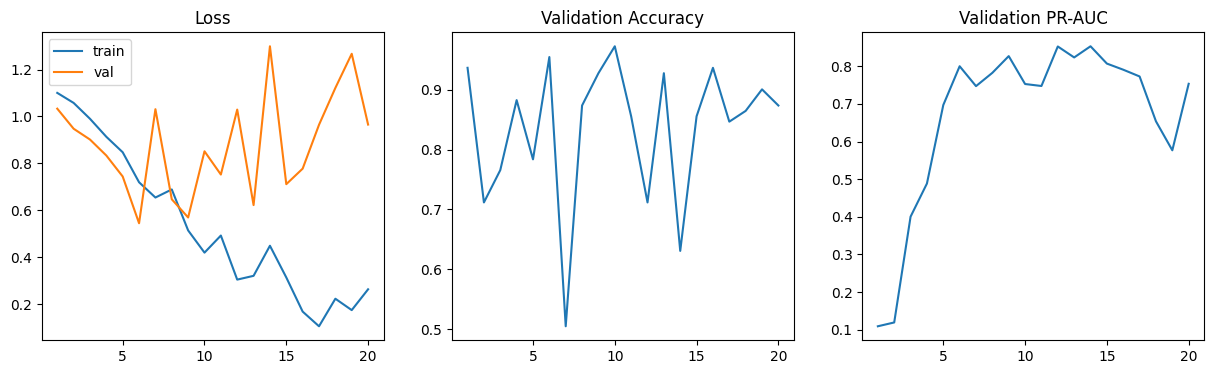

In [ ]:
# WEIGHTED BCE PERFORMANCE

# Loss, accuracy and PR-AUC plots

import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/CARDIUM/tuning_weighted_bce_pw_10_0/training_history.csv"
)

best_fold = (
    history.groupby("fold")["val_pr_auc"]
    .max()
    .idxmax()
)

fold_history = history[history["fold"] == best_fold]

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.plot(fold_history["epoch"], fold_history["train_loss"], label="train")
plt.plot(fold_history["epoch"], fold_history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(fold_history["epoch"], fold_history["val_accuracy"])
plt.title("Validation Accuracy")

plt.subplot(1,3,3)
plt.plot(fold_history["epoch"], fold_history["val_pr_auc"])
plt.title("Validation PR-AUC")

plt.show()

In [ ]:
# Confusion matrices
preds = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/CARDIUM/tuning_weighted_bce_pw_10_0/fold_test_predictions.csv"
)

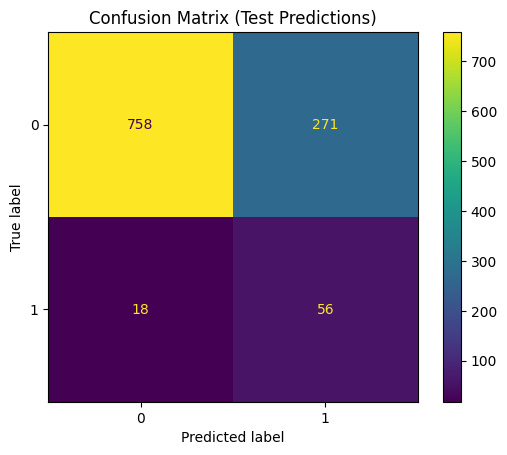

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

threshold = 0.5
preds["y_pred"] = (preds["y_prob"] >= threshold).astype(int)

cm = confusion_matrix(preds["y_true"], preds["y_pred"])

ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix (Test Predictions)")
plt.show()

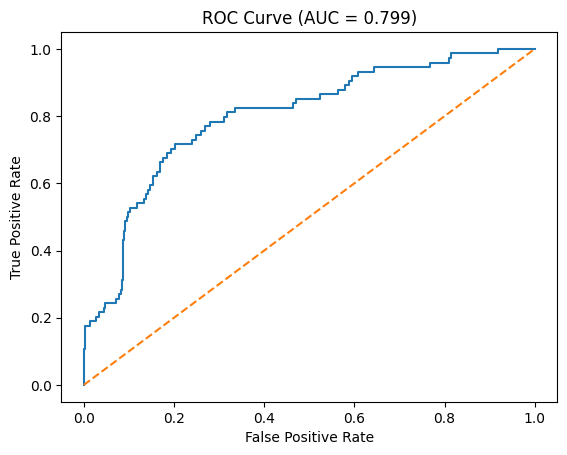

In [ ]:
# ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(preds["y_true"], preds["y_prob"])
roc_auc = roc_auc_score(preds["y_true"], preds["y_prob"])

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

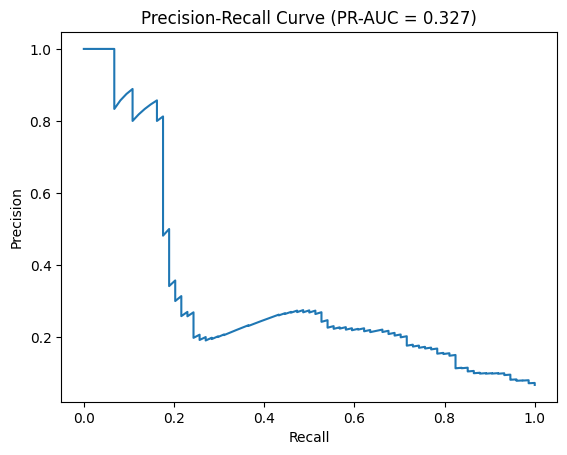

In [ ]:
# PR Curve

from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(
    preds["y_true"],
    preds["y_prob"]
)

pr_auc = average_precision_score(
    preds["y_true"],
    preds["y_prob"]
)

plt.plot(recall, precision)
plt.title(f"Precision-Recall Curve (PR-AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

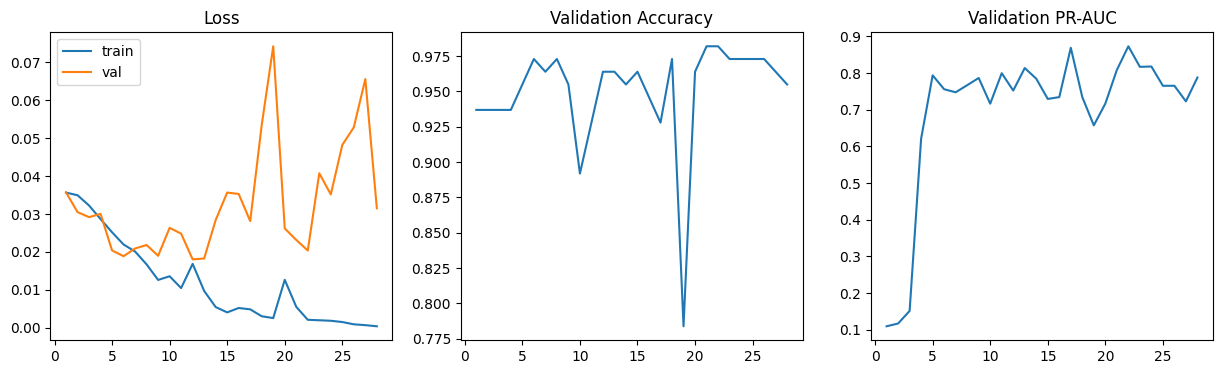

In [ ]:
# FOCAL LOSS PERFORMANCE

# Loss, accuracy and PR-AUC plots

import pandas as pd
import matplotlib.pyplot as plt

history = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/CARDIUM/tuning_focal_a_0_75_g_2_0/training_history.csv"
)

best_fold = (
    history.groupby("fold")["val_pr_auc"]
    .max()
    .idxmax()
)

fold_history = history[history["fold"] == best_fold]

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.plot(fold_history["epoch"], fold_history["train_loss"], label="train")
plt.plot(fold_history["epoch"], fold_history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(fold_history["epoch"], fold_history["val_accuracy"])
plt.title("Validation Accuracy")

plt.subplot(1,3,3)
plt.plot(fold_history["epoch"], fold_history["val_pr_auc"])
plt.title("Validation PR-AUC")

plt.show()

In [ ]:
# Confusion matrices
preds = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/CARDIUM/tuning_focal_a_0_75_g_2_0/fold_test_predictions.csv"
)

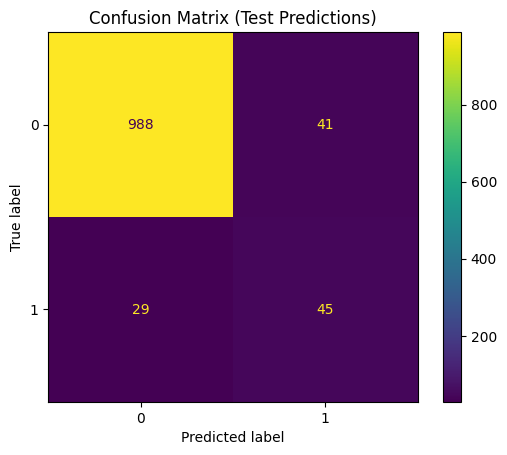

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

threshold = 0.5
preds["y_pred"] = (preds["y_prob"] >= threshold).astype(int)

cm = confusion_matrix(preds["y_true"], preds["y_pred"])

ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix (Test Predictions)")
plt.show()

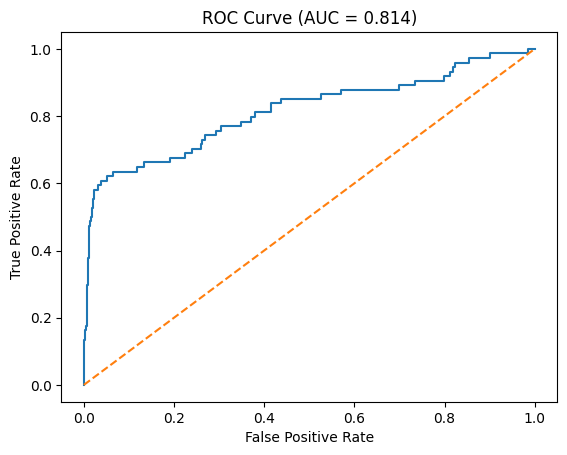

In [ ]:
# ROC Curve
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(preds["y_true"], preds["y_prob"])
roc_auc = roc_auc_score(preds["y_true"], preds["y_prob"])

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

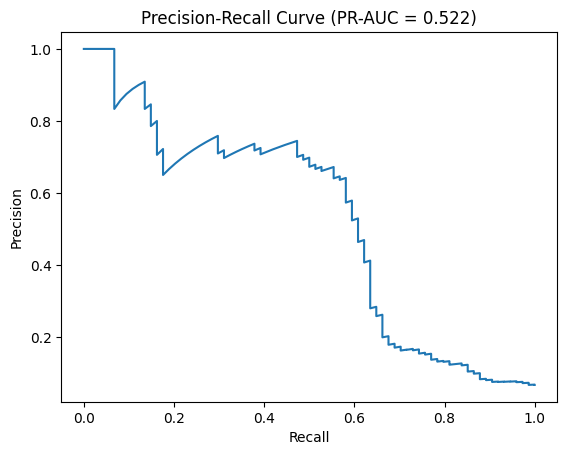

In [ ]:
# PR Curve

from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(
    preds["y_true"],
    preds["y_prob"]
)

pr_auc = average_precision_score(
    preds["y_true"],
    preds["y_prob"]
)

plt.plot(recall, precision)
plt.title(f"Precision-Recall Curve (PR-AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

Apply Platt Scaling to the Best Models

In [3]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    recall_score,
    precision_score,
    roc_auc_score,
    average_precision_score,
)


class PlattScaler:
    def __init__(self):
        # Simple logistic regression for Platt scaling
        self.model = LogisticRegression()

    def fit(self, y_prob, y_true):
        y_prob = np.asarray(y_prob).reshape(-1, 1)
        y_true = np.asarray(y_true).astype(int)
        self.model.fit(y_prob, y_true)

    def transform(self, y_prob):
        y_prob = np.asarray(y_prob).reshape(-1, 1)
        return self.model.predict_proba(y_prob)[:, 1]

In [4]:
def compute_threshold_metrics(y_true, y_prob, threshold):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return {
        "threshold": threshold,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1": f1,
        "fnr": fnr,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    }

In [5]:
def find_best_threshold(
    y_true,
    y_prob,
    metric="f1",
    min_sensitivity=None,
    thresholds=None,
):
    """
    metric:
        - "f1"                  -> choose threshold with best F1
        - "youden"              -> maximize sensitivity + specificity - 1
        - "sensitivity_floor"   -> among thresholds meeting min_sensitivity,
                                   choose one with best specificity

    min_sensitivity:
        used only when metric="sensitivity_floor"
    """
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)

    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)

    all_results = []

    for thr in thresholds:
        row = compute_threshold_metrics(y_true, y_prob, thr)

        if metric == "youden":
            row["selection_score"] = row["sensitivity"] + row["specificity"] - 1

        elif metric == "sensitivity_floor":
            if min_sensitivity is None:
                raise ValueError("min_sensitivity must be provided for sensitivity_floor")
            if row["sensitivity"] >= min_sensitivity:
                row["selection_score"] = row["specificity"]
            else:
                row["selection_score"] = -np.inf

        else:  # default = F1
            row["selection_score"] = row["f1"]

        all_results.append(row)

    results_df = pd.DataFrame(all_results)
    best_idx = results_df["selection_score"].idxmax()
    best_row = results_df.loc[best_idx].to_dict()

    return best_row, results_df

In [6]:
def calibrate_and_tune_threshold(
    val_predictions_df,
    test_predictions_df,
    prob_col="y_prob",
    label_col="y_true",
    threshold_metric="f1",
    min_sensitivity=None,
):
    """
    Fits Platt scaling on validation predictions only.
    Applies to validation and test predictions.
    Tunes threshold on calibrated validation probabilities only.
    Applies chosen threshold to both validation and test calibrated probabilities.
    """

    # Defensive copy
    val_df = val_predictions_df.copy()
    test_df = test_predictions_df.copy()

    # Save raw probability explicitly
    val_df["y_prob_raw"] = val_df[prob_col]
    test_df["y_prob_raw"] = test_df[prob_col]

    # 1. Fit Platt scaler on validation only
    scaler = PlattScaler()
    scaler.fit(
        y_prob=val_df[prob_col].values,
        y_true=val_df[label_col].values,
    )

    # 2. Transform validation and test probabilities
    val_df["y_prob_calibrated"] = scaler.transform(val_df[prob_col].values)
    test_df["y_prob_calibrated"] = scaler.transform(test_df[prob_col].values)

    # 3. Threshold tuning on calibrated validation probabilities only
    best_threshold_row, threshold_results_df = find_best_threshold(
        y_true=val_df[label_col].values,
        y_prob=val_df["y_prob_calibrated"].values,
        metric=threshold_metric,
        min_sensitivity=min_sensitivity,
    )

    best_threshold = float(best_threshold_row["threshold"])

    # 4. Apply chosen threshold
    val_df["y_pred_calibrated"] = (
        val_df["y_prob_calibrated"] >= best_threshold
    ).astype(int)

    test_df["y_pred_calibrated"] = (
        test_df["y_prob_calibrated"] >= best_threshold
    ).astype(int)

    # Optional raw 0.5 predictions for comparison
    val_df["y_pred_raw_0p5"] = (val_df["y_prob_raw"] >= 0.5).astype(int)
    test_df["y_pred_raw_0p5"] = (test_df["y_prob_raw"] >= 0.5).astype(int)

    # Summary metrics
    summary = {
        "val_auc_raw": roc_auc_score(val_df[label_col], val_df["y_prob_raw"]),
        "val_auc_calibrated": roc_auc_score(val_df[label_col], val_df["y_prob_calibrated"]),
        "test_auc_raw": roc_auc_score(test_df[label_col], test_df["y_prob_raw"]),
        "test_auc_calibrated": roc_auc_score(test_df[label_col], test_df["y_prob_calibrated"]),
        "val_auprc_raw": average_precision_score(val_df[label_col], val_df["y_prob_raw"]),
        "val_auprc_calibrated": average_precision_score(val_df[label_col], val_df["y_prob_calibrated"]),
        "test_auprc_raw": average_precision_score(test_df[label_col], test_df["y_prob_raw"]),
        "test_auprc_calibrated": average_precision_score(test_df[label_col], test_df["y_prob_calibrated"]),
        "best_threshold": best_threshold,
        "threshold_metric": threshold_metric,
    }

    if min_sensitivity is not None:
        summary["min_sensitivity"] = min_sensitivity

    return {
        "val_predictions_df": val_df,
        "test_predictions_df": test_df,
        "threshold_results_df": threshold_results_df,
        "best_threshold_row": best_threshold_row,
        "summary": summary,
        "scaler": scaler,
    }

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np

base_path = Path("/content/drive/MyDrive/Colab Notebooks/CARDIUM")

best_models = {
    "bce": {
        "experiment": "outputs_bce",
        "label": "bce_default",
    },
    "weighted_bce": {
        "experiment": "tuning_weighted_bce_pw_10_0",
        "label": "weighted_bce_pw_10",
    },
    "focal": {
        "experiment": "tuning_focal_a_0_75_g_2_0",
        "label": "focal_a_0_75_g_2",
    },
}

In [10]:
# Check fold_val_predictions

loss_type, info = next(iter(best_models.items()))

experiment_dir = base_path / info["experiment"]

val_df = pd.read_csv(experiment_dir / "fold_val_predictions.csv")

print(val_df.head())
print(val_df.columns)
print(val_df.shape)
print(val_df["fold"].unique())
print(val_df["y_prob"].min(), val_df["y_prob"].max())

   fold  y_true    y_prob
0     1     1.0  0.438531
1     1     1.0  0.971561
2     1     1.0  0.972911
3     1     1.0  0.935453
4     1     1.0  0.973501
Index(['fold', 'y_true', 'y_prob'], dtype='object')
(333, 3)
[1 2 3]
0.0037856479175388 0.9735012650489808


In [11]:
# Check fold_test_predictions

test_df = pd.read_csv(experiment_dir / "fold_test_predictions.csv")

print(test_df.head())
print(test_df.columns)
print(test_df.shape)
print(test_df["fold"].unique())
print(test_df["y_prob"].min(), test_df["y_prob"].max())

   fold  y_true    y_prob
0     1     1.0  0.974809
1     1     1.0  0.074292
2     1     1.0  0.971732
3     1     1.0  0.973907
4     1     1.0  0.975226
Index(['fold', 'y_true', 'y_prob'], dtype='object')
(1103, 3)
[1 2 3]
0.0037677506916224 0.976041615009308


In [12]:
# calibrate and tune thresholds

import pandas as pd

# Models included in final threshold-tuning comparison
# Weighted BCE did not make sense in the threshold tuning
# It predicted everything as positive
threshold_tuning_models = {"bce", "focal"}

calibration_rows = []
threshold_rows = []

for loss_type, info in best_models.items():
    experiment_dir = base_path / info["experiment"]

    val_path = experiment_dir / "fold_val_predictions.csv"
    test_path = experiment_dir / "fold_test_predictions.csv"

    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    # Basic safety checks
    assert {"fold", "y_true", "y_prob"}.issubset(val_df.columns)
    assert {"fold", "y_true", "y_prob"}.issubset(test_df.columns)
    assert val_df["y_prob"].between(0, 1).all()
    assert test_df["y_prob"].between(0, 1).all()

    # Calibrate all models
    results = calibrate_and_tune_threshold(
        val_predictions_df=val_df,
        test_predictions_df=test_df,
        prob_col="y_prob",
        label_col="y_true",
        threshold_metric="sensitivity_floor",
        min_sensitivity=0.80,
    )

    val_predictions_calibrated_df = results["val_predictions_df"]
    test_predictions_calibrated_df = results["test_predictions_df"]
    threshold_results_df = results["threshold_results_df"]
    best_threshold_row = results["best_threshold_row"]
    summary = results["summary"]

    # Save calibrated prediction files for every model
    val_predictions_calibrated_df.to_csv(
        experiment_dir / "fold_val_predictions_calibrated.csv",
        index=False,
    )
    test_predictions_calibrated_df.to_csv(
        experiment_dir / "fold_test_predictions_calibrated.csv",
        index=False,
    )

    # Save calibration summary for every model
    calibration_rows.append({
        "loss_type": loss_type,
        "experiment": info["experiment"],
        "included_in_threshold_tuning": loss_type in threshold_tuning_models,
        "val_auc_raw": summary["val_auc_raw"],
        "val_auc_calibrated": summary["val_auc_calibrated"],
        "test_auc_raw": summary["test_auc_raw"],
        "test_auc_calibrated": summary["test_auc_calibrated"],
        "val_auprc_raw": summary["val_auprc_raw"],
        "val_auprc_calibrated": summary["val_auprc_calibrated"],
        "test_auprc_raw": summary["test_auprc_raw"],
        "test_auprc_calibrated": summary["test_auprc_calibrated"],
    })

    # Only keep threshold-tuning outputs for selected models
    if loss_type in threshold_tuning_models:
        threshold_results_df.to_csv(
            experiment_dir / "threshold_tuning_calibrated.csv",
            index=False,
        )

        threshold_rows.append({
            "loss_type": loss_type,
            "experiment": info["experiment"],
            "threshold_metric": summary["threshold_metric"],
            "min_sensitivity": summary.get("min_sensitivity"),
            "best_threshold": best_threshold_row["threshold"],
            "val_sensitivity_at_best_threshold": best_threshold_row["sensitivity"],
            "val_specificity_at_best_threshold": best_threshold_row["specificity"],
            "val_precision_at_best_threshold": best_threshold_row["precision"],
            "val_f1_at_best_threshold": best_threshold_row["f1"],
            "val_fnr_at_best_threshold": best_threshold_row["fnr"],
        })

calibration_df = pd.DataFrame(calibration_rows)
threshold_tuning_df = pd.DataFrame(threshold_rows)

calibration_df.to_csv(base_path / "calibration_summary_all_models.csv", index=False)
threshold_tuning_df.to_csv(base_path / "threshold_tuning_summary_bce_focal.csv", index=False)

calibration_df, threshold_tuning_df

(      loss_type                   experiment  included_in_threshold_tuning  \
 0           bce                  outputs_bce                          True   
 1  weighted_bce  tuning_weighted_bce_pw_10_0                         False   
 2         focal    tuning_focal_a_0_75_g_2_0                          True   
 
    val_auc_raw  val_auc_calibrated  test_auc_raw  test_auc_calibrated  \
 0     0.842882            0.842882      0.772503             0.772503   
 1     0.738088            0.738088      0.799031             0.799031   
 2     0.835721            0.835721      0.814357             0.814357   
 
    val_auprc_raw  val_auprc_calibrated  test_auprc_raw  test_auprc_calibrated  
 0       0.582987              0.582987        0.480346               0.480346  
 1       0.367529              0.367529        0.327371               0.327371  
 2       0.637542              0.637542        0.522183               0.522183  ,
   loss_type                 experiment   threshold_metric 

In [13]:
# Because Weighted BCE behaved so strangly and predicted everything as positive
# calculate the equivalent threshold for the calibrated predictions to 0.5 from
# the uncalibrated original model predictions

from sklearn.linear_model import LogisticRegression
import numpy as np

class PlattScaler:
    def __init__(self):
        self.model = LogisticRegression()

    def fit(self, y_prob, y_true):
        y_prob = np.array(y_prob).reshape(-1, 1)
        self.model.fit(y_prob, y_true)

    def transform(self, y_prob):
        y_prob = np.array(y_prob).reshape(-1, 1)
        return self.model.predict_proba(y_prob)[:, 1]

def get_platt_equivalent_threshold_for_weighted_bce(
    val_predictions_df,
    prob_col="y_prob",
    label_col="y_true",
    raw_threshold=0.5,
):
    scaler = PlattScaler()
    scaler.fit(
        y_prob=val_predictions_df[prob_col].values,
        y_true=val_predictions_df[label_col].values,
    )

    calibrated_threshold = float(
        scaler.transform(np.array([raw_threshold]))[0]
    )

    return calibrated_threshold, scaler

In [14]:
# Find equivalent threshold to 0.5 for weighted BCE


base_path = Path("/content/drive/MyDrive/Colab Notebooks/CARDIUM")

best_weighted_bce_model = {
    "weighted_bce": {
        "experiment": "tuning_weighted_bce_pw_10_0",
        "label": "weighted_bce_pw_10",
    }
}

exp_name = best_weighted_bce_model["weighted_bce"]["experiment"]

val_predictions_df = pd.read_csv(base_path / exp_name / "fold_val_predictions.csv")
test_predictions_df = pd.read_csv(base_path / exp_name / "fold_test_predictions.csv")

weighted_bce_cal_threshold, weighted_bce_scaler = (
    get_platt_equivalent_threshold_for_weighted_bce(
        val_predictions_df=val_predictions_df,
        prob_col="y_prob",
        label_col="y_true",
        raw_threshold=0.5,
    )
)

print("Calibrated threshold equivalent to raw 0.5:", weighted_bce_cal_threshold)

Calibrated threshold equivalent to raw 0.5: 0.07106078856049235


In [15]:
# Apply the new threshold to the calibrated Weighted BCE loss data

val_df = val_predictions_df.copy()
test_df = test_predictions_df.copy()

val_df["y_prob_calibrated"] = weighted_bce_scaler.transform(val_df["y_prob"].values)
test_df["y_prob_calibrated"] = weighted_bce_scaler.transform(test_df["y_prob"].values)

val_df["y_pred_calibrated"] = (
    val_df["y_prob_calibrated"] >= weighted_bce_cal_threshold
).astype(int)

test_df["y_pred_calibrated"] = (
    test_df["y_prob_calibrated"] >= weighted_bce_cal_threshold
).astype(int)

In [16]:
from sklearn.metrics import confusion_matrix, precision_score, f1_score
import pandas as pd

def compute_metrics_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return {
        "threshold": threshold,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "f1": f1,
        "fnr": fnr,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    }

weighted_bce_threshold_metrics = compute_metrics_at_threshold(
    y_true=val_df["y_true"].values,
    y_prob=val_df["y_prob_calibrated"].values,
    threshold=weighted_bce_cal_threshold,
)

threshold_rows.append({
    "loss_type": "weighted_bce",
    "experiment": best_weighted_bce_model["weighted_bce"]["experiment"],
    "threshold_metric": "fixed_raw_0.5_mapped_to_calibrated",
    "min_sensitivity": None,
    "best_threshold": weighted_bce_threshold_metrics["threshold"],
    "val_sensitivity_at_best_threshold": weighted_bce_threshold_metrics["sensitivity"],
    "val_specificity_at_best_threshold": weighted_bce_threshold_metrics["specificity"],
    "val_precision_at_best_threshold": weighted_bce_threshold_metrics["precision"],
    "val_f1_at_best_threshold": weighted_bce_threshold_metrics["f1"],
    "val_fnr_at_best_threshold": weighted_bce_threshold_metrics["fnr"],
})

print(pd.DataFrame([threshold_rows[-1]]))

      loss_type                   experiment  \
0  weighted_bce  tuning_weighted_bce_pw_10_0   

                     threshold_metric min_sensitivity  best_threshold  \
0  fixed_raw_0.5_mapped_to_calibrated            None        0.071061   

   val_sensitivity_at_best_threshold  val_specificity_at_best_threshold  \
0                           0.636364                           0.691318   

   val_precision_at_best_threshold  val_f1_at_best_threshold  \
0                         0.127273                  0.212121   

   val_fnr_at_best_threshold  
0                   0.363636  


In [17]:
# Output dataframes

calibration_df = pd.DataFrame(calibration_rows)
threshold_tuning_df = pd.DataFrame(threshold_rows)

calibration_df.to_csv(base_path / "calibration_summary_all_models.csv", index=False)
threshold_tuning_df.to_csv(base_path / "threshold_tuning_summary_bce_focal.csv", index=False)

calibration_df, threshold_tuning_df

(      loss_type                   experiment  included_in_threshold_tuning  \
 0           bce                  outputs_bce                          True   
 1  weighted_bce  tuning_weighted_bce_pw_10_0                         False   
 2         focal    tuning_focal_a_0_75_g_2_0                          True   
 
    val_auc_raw  val_auc_calibrated  test_auc_raw  test_auc_calibrated  \
 0     0.842882            0.842882      0.772503             0.772503   
 1     0.738088            0.738088      0.799031             0.799031   
 2     0.835721            0.835721      0.814357             0.814357   
 
    val_auprc_raw  val_auprc_calibrated  test_auprc_raw  test_auprc_calibrated  
 0       0.582987              0.582987        0.480346               0.480346  
 1       0.367529              0.367529        0.327371               0.327371  
 2       0.637542              0.637542        0.522183               0.522183  ,
       loss_type                   experiment  \
 0        

In [33]:
# Create a table for the report from the validation set

final_models = [
    "bce",
    "weighted_bce",
    "focal"
]

report_df = threshold_tuning_df[
    threshold_tuning_df["loss_type"].isin(final_models)
].copy()

report_df = report_df[[
    "loss_type",
    "best_threshold",
    "val_sensitivity_at_best_threshold",
    "val_specificity_at_best_threshold",
    "val_precision_at_best_threshold",
    "val_f1_at_best_threshold",
    "val_fnr_at_best_threshold"
]]

report_df.rename(columns={
    "loss_type": "Loss Function",
    "best_threshold": "Threshold",
    "val_sensitivity_at_best_threshold": "Sensitivity",
    "val_specificity_at_best_threshold": "Specificity",
    "val_precision_at_best_threshold": "Precision",
    "val_f1_at_best_threshold": "F1 Score",
    "val_fnr_at_best_threshold": "FNR"
}, inplace=True)

report_df["Loss Function"] = report_df["Loss Function"].replace({
    "bce": "BCE",
    "weighted_bce": "Weighted BCE",
    "focal": "Focal Loss"
})

metric_cols = [
    "Threshold",
    "Sensitivity",
    "Specificity",
    "Precision",
    "F1 Score",
    "FNR"
]

report_df[metric_cols] = report_df[metric_cols].round(3)

report_df = report_df.sort_values("Loss Function")

report_df

,Loss Function,Threshold,Sensitivity,Specificity,Precision,F1 Score,FNR
0,BCE,0.050,0.909,0.457,0.106,0.190,0.091
1,Focal Loss,0.050,0.818,0.617,0.131,0.226,0.182
2,Weighted BCE,0.071,0.636,0.691,0.127,0.212,0.364


In [39]:
# Output table to Latex

base_path = Path("/content/drive/MyDrive/Colab Notebooks/CARDIUM")

report_df = report_df.reset_index(drop=True)

results_calibrated = report_df.to_latex(
    index=False,
    escape=False,
    column_format="lccccc",
    caption="Validation-set operating-point performance after Platt calibration.",
    label="tab:validation_threshold_performance"
)

output_path = base_path / "validation_calibrated.tex"

with open(output_path, "w") as f:
    f.write(results_calibrated)

print("Saved to:", output_path)

Saved to: /content/drive/MyDrive/Colab Notebooks/CARDIUM/validation_calibrated.tex


In [24]:
# Helper function to compute test metrics

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_score,
    f1_score,
)

def compute_test_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    fnr = fn / (fn + tp)

    auc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)

    return {
        "AUROC": auc,
        "AUPRC": auprc,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1": f1,
        "FNR": fnr,
        "Threshold": threshold,
    }

def compute_operating_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    return {
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "F1": f1,
        "FNR": fnr,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
    }


In [22]:
# Create table for report of ROC, PR for the test set

table2_base_df = calibration_df.merge(
    threshold_tuning_df[
        [
            "loss_type",
            "experiment",
            "best_threshold",
        ]
    ],
    on=["loss_type", "experiment"],
    how="left",
)

In [25]:
import pandas as pd

table2_rows = []

for _, row in table2_base_df.iterrows():
    loss_type = row["loss_type"]
    experiment = row["experiment"]
    threshold = row["best_threshold"]

    experiment_dir = base_path / experiment
    test_calibrated_path = experiment_dir / "fold_test_predictions_calibrated.csv"

    test_df = pd.read_csv(test_calibrated_path)

    # Safety checks
    assert {"y_true", "y_prob_calibrated"}.issubset(test_df.columns)

    metrics = compute_operating_metrics(
        y_true=test_df["y_true"].values,
        y_prob=test_df["y_prob_calibrated"].values,
        threshold=threshold,
    )

    table2_rows.append({
        "Loss Function": loss_type,
        "AUROC": row["test_auc_calibrated"],
        "AUPRC": row["test_auprc_calibrated"],
        "Sensitivity": metrics["Sensitivity"],
        "Specificity": metrics["Specificity"],
        "Precision": metrics["Precision"],
        "F1": metrics["F1"],
        "FNR": metrics["FNR"],
        "Threshold": threshold,
    })

table2_df = pd.DataFrame(table2_rows)
table2_df

,Loss Function,AUROC,AUPRC,Sensitivity,Specificity,Precision,F1,FNR,Threshold
0,bce,0.772503,0.480346,0.797297,0.490768,0.101201,0.179604,0.202703,0.050000
1,weighted_bce,0.799031,0.327371,0.756757,0.736638,0.171254,0.279302,0.243243,0.071061
2,focal,0.814357,0.522183,0.770270,0.688047,0.150794,0.252212,0.229730,0.050000


In [36]:
table2_df["Loss Function"] = table2_df["Loss Function"].replace({
    "bce": "BCE",
    "weighted_bce": "Weighted BCE",
    "focal": "Focal Loss",
})

metric_cols = [
    "AUROC",
    "AUPRC",
    "Sensitivity",
    "Specificity",
    "Precision",
    "F1",
    "FNR",
    "Threshold",
]

table2_df[metric_cols] = table2_df[metric_cols].round(3)

# Optional row order
table2_df["Loss Function"] = pd.Categorical(
    table2_df["Loss Function"],
    categories=["BCE", "Weighted BCE", "Focal Loss"],
    ordered=True
)

table2_df = table2_df.sort_values("Loss Function").reset_index(drop=True)

table2_df

,Loss Function,AUROC,AUPRC,Sensitivity,Specificity,Precision,F1,FNR,Threshold
0,BCE,0.773,0.480,0.797,0.491,0.101,0.180,0.203,0.050
1,Weighted BCE,0.799,0.327,0.757,0.737,0.171,0.279,0.243,0.071
2,Focal Loss,0.814,0.522,0.770,0.688,0.151,0.252,0.230,0.050


In [38]:
# Output table to Latex

base_path = Path("/content/drive/MyDrive/Colab Notebooks/CARDIUM")

table2_df = table2_df.reset_index(drop=True)

test_calibrated = table2_df.to_latex(
    index=False,
    escape=False,
    column_format="lccccc",
    caption="Test-set operating-point performance after Platt calibration.",
    label="tab:test_threshold_performance"
)

output_path = base_path / "test_calibrated.tex"

with open(output_path, "w") as f:
    f.write(test_calibrated)

print("Saved to:", output_path)

Saved to: /content/drive/MyDrive/Colab Notebooks/CARDIUM/test_calibrated.tex


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss


def plot_probability_histograms(df, model_name, split):
    plt.figure(figsize=(6,4))

    plt.hist(df["y_prob_raw"], bins=30, alpha=0.5, label="Raw")
    plt.hist(df["y_prob_calibrated"], bins=30, alpha=0.5, label="Calibrated")

    plt.title(f"{model_name} ({split}) Probability Distribution")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.legend()
    plt.show()


def plot_classwise_distributions(df, model_name, split):
    positives = df[df["y_true"] == 1]
    negatives = df[df["y_true"] == 0]

    plt.figure(figsize=(6,4))

    plt.hist(
        positives["y_prob_calibrated"],
        bins=30,
        alpha=0.5,
        label="Positives"
    )

    plt.hist(
        negatives["y_prob_calibrated"],
        bins=30,
        alpha=0.5,
        label="Negatives"
    )

    plt.title(f"{model_name} ({split}) Classwise Calibrated Distribution")
    plt.xlabel("Predicted probability")
    plt.ylabel("Count")
    plt.legend()
    plt.show()


def plot_calibration_curve(df, model_name, split):
    y_true = df["y_true"]

    prob_true_raw, prob_pred_raw = calibration_curve(
        y_true,
        df["y_prob_raw"],
        n_bins=10
    )

    prob_true_cal, prob_pred_cal = calibration_curve(
        y_true,
        df["y_prob_calibrated"],
        n_bins=10
    )

    plt.figure(figsize=(5,5))

    plt.plot(prob_pred_raw, prob_true_raw, marker="o", label="Raw")
    plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="Calibrated")

    plt.plot([0,1], [0,1], linestyle="--")

    plt.title(f"{model_name} ({split}) Calibration Curve")
    plt.xlabel("Predicted probability")
    plt.ylabel("Observed frequency")
    plt.legend()
    plt.show()


def compute_brier_scores(df, model_name, split):
    raw = brier_score_loss(df["y_true"], df["y_prob_raw"])
    calibrated = brier_score_loss(df["y_true"], df["y_prob_calibrated"])

    print(f"{model_name} ({split})")
    print("  Brier score raw:", round(raw, 4))
    print("  Brier score calibrated:", round(calibrated, 4))
    print()

Model: bce | Validation set


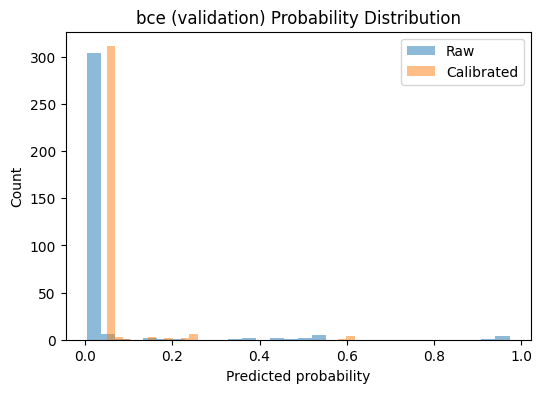

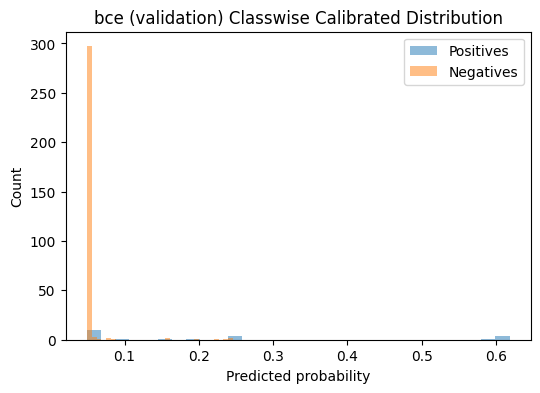

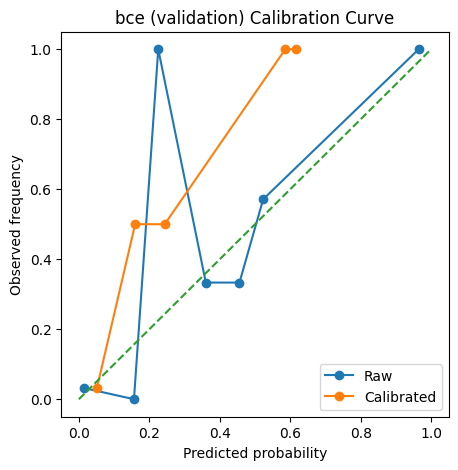

bce (validation)
  Brier score raw: 0.0406
  Brier score calibrated: 0.0459

Model: weighted_bce | Validation set


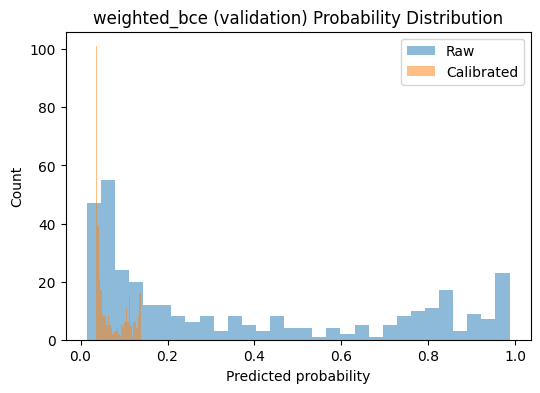

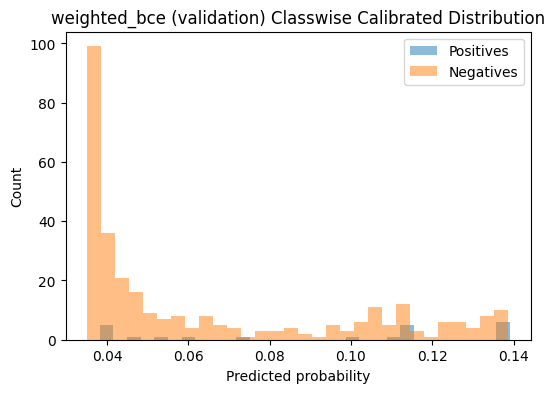

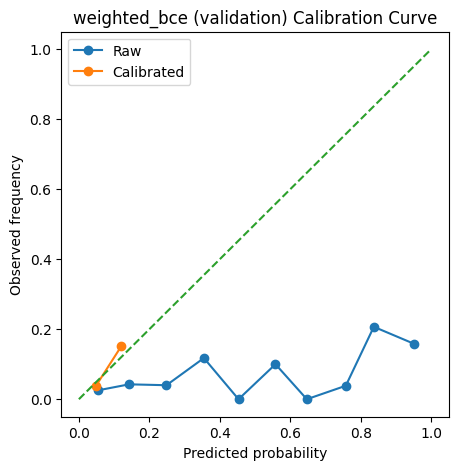

weighted_bce (validation)
  Brier score raw: 0.2369
  Brier score calibrated: 0.0594

Model: focal | Validation set


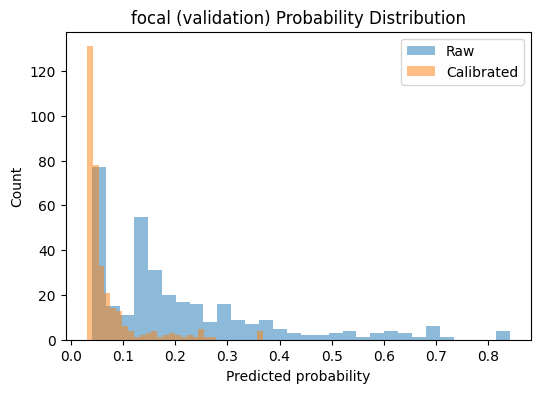

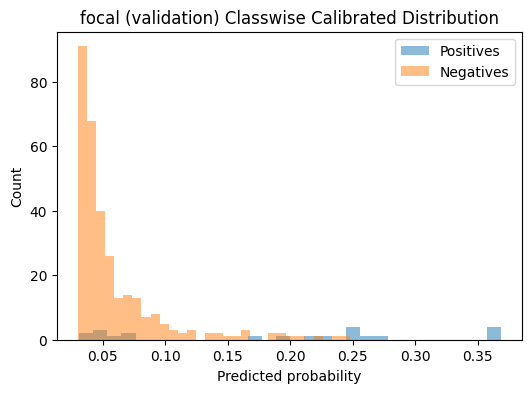

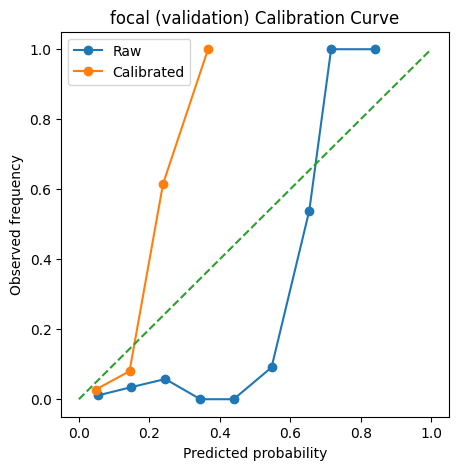

focal (validation)
  Brier score raw: 0.0709
  Brier score calibrated: 0.0484



In [ ]:
for loss_type, info in best_models.items():

    experiment_dir = base_path / info["experiment"]

    val_path = experiment_dir / "fold_val_predictions_calibrated.csv"

    df = pd.read_csv(val_path)

    print("=" * 50)
    print(f"Model: {loss_type} | Validation set")
    print("=" * 50)

    plot_probability_histograms(df, loss_type, "validation")
    plot_classwise_distributions(df, loss_type, "validation")
    plot_calibration_curve(df, loss_type, "validation")
    compute_brier_scores(df, loss_type, "validation")

Model: bce | Test set


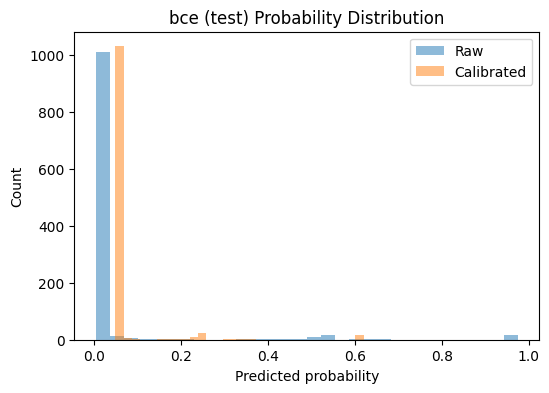

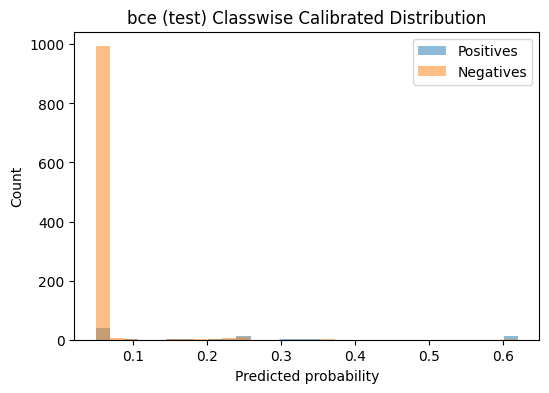

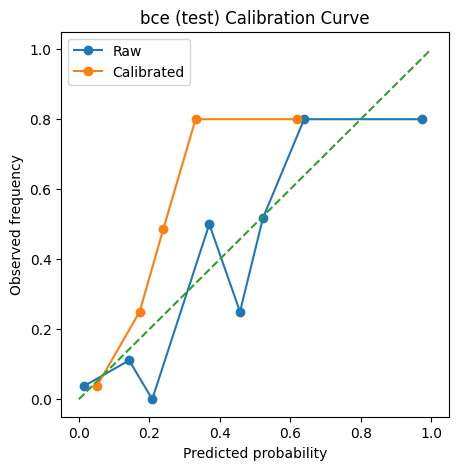

bce (test)
  Brier score raw: 0.047
  Brier score calibrated: 0.0497

Model: weighted_bce | Test set


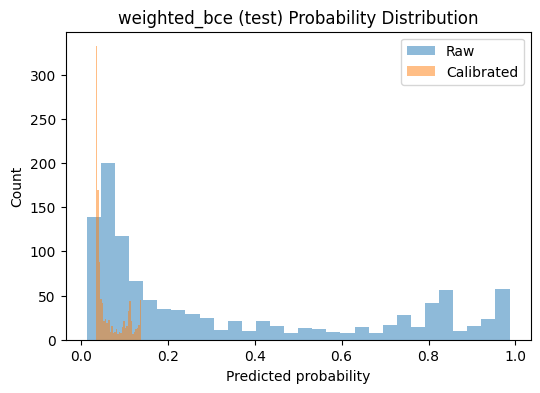

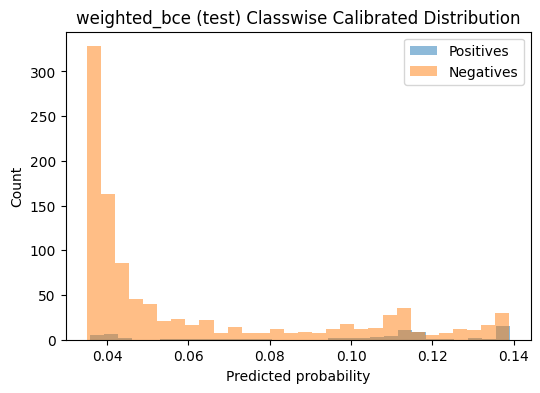

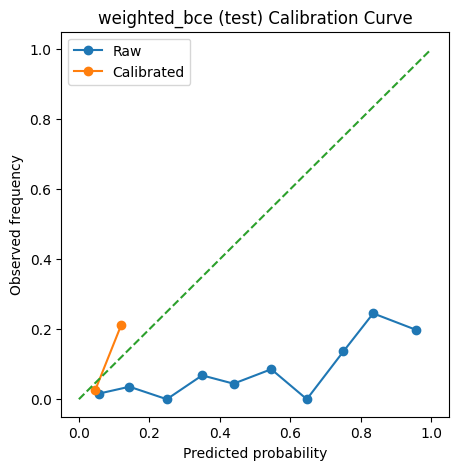

weighted_bce (test)
  Brier score raw: 0.1942
  Brier score calibrated: 0.0587

Model: focal | Test set


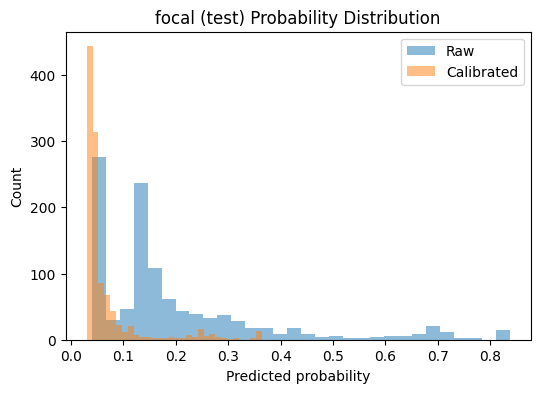

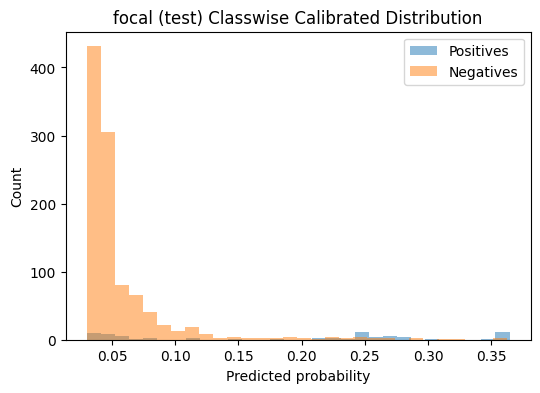

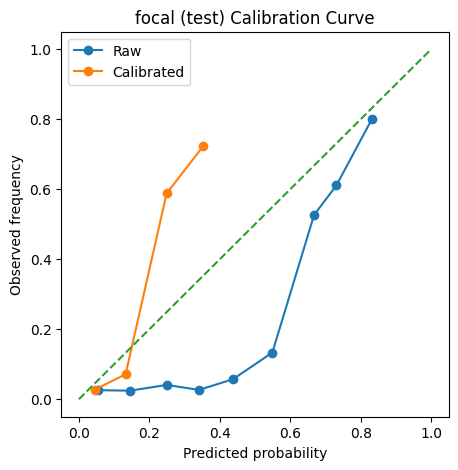

focal (test)
  Brier score raw: 0.0686
  Brier score calibrated: 0.0495



In [ ]:
for loss_type, info in best_models.items():

    experiment_dir = base_path / info["experiment"]

    test_path = experiment_dir / "fold_test_predictions_calibrated.csv"

    df = pd.read_csv(test_path)

    print("=" * 50)
    print(f"Model: {loss_type} | Test set")
    print("=" * 50)

    plot_probability_histograms(df, loss_type, "test")
    plot_classwise_distributions(df, loss_type, "test")
    plot_calibration_curve(df, loss_type, "test")
    compute_brier_scores(df, loss_type, "test")

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(cm, model_name, save_path=None):
    tn, fp, fn, tp = cm.ravel()

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Predicted Negative", "Predicted Positive"],
        yticklabels=["True Negative", "True Positive"]
    )

    plt.title(f"{model_name} Confusion Matrix (Test Set)")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

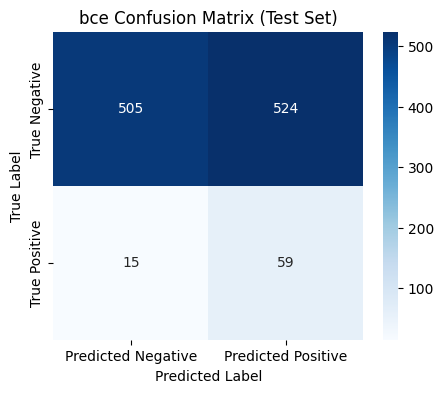

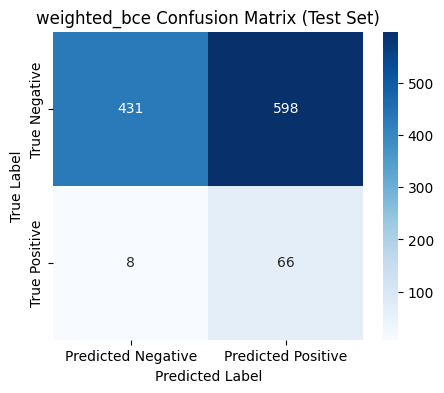

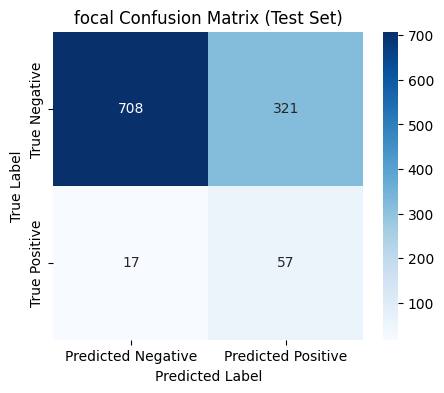

,model,TP,FP,TN,FN,sensitivity,specificity,precision,fnr
0,bce,59,524,505,15,0.797297,0.490768,0.101201,0.202703
1,weighted_bce,66,598,431,8,0.891892,0.418853,0.099398,0.108108
2,focal,57,321,708,17,0.770270,0.688047,0.150794,0.229730


In [42]:
final_models = ["bce", "weighted_bce", "focal"]

confusion_summary = []

for loss_type in final_models:

    experiment_dir = base_path / best_models[loss_type]["experiment"]

    df = pd.read_csv(
        experiment_dir / "fold_test_predictions_calibrated.csv"
    )

    cm = confusion_matrix(
        df["y_true"],
        df["y_pred_calibrated"]
    )

    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = tp / (tp + fp)
    fnr = fn / (fn + tp)

    confusion_summary.append({
        "model": loss_type,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "fnr": fnr,
    })

    # Plot confusion matrix
    plot_confusion_matrix(
        cm,
        model_name=loss_type,
        save_path=experiment_dir / "confusion_matrix_test.png"
    )

confusion_df = pd.DataFrame(confusion_summary)

confusion_df

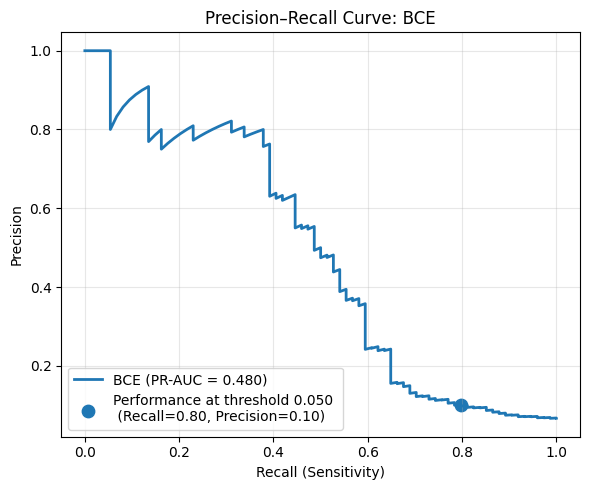

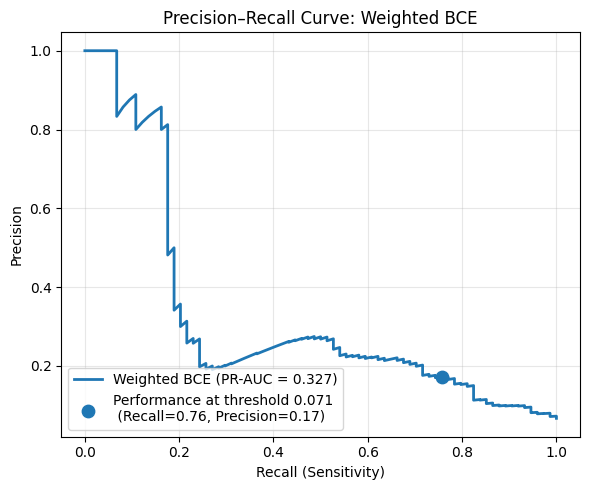

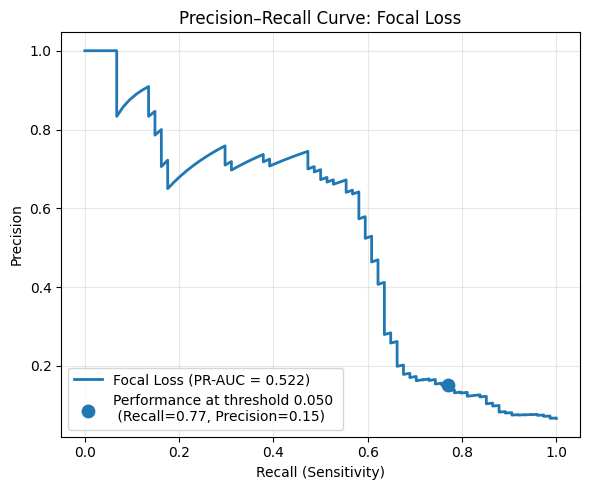

,model,threshold,pr_auc,operating_point_precision,operating_point_recall
0,bce,0.050,0.480346,0.101201,0.797297
1,weighted_bce,0.071,0.327371,0.171254,0.756757
2,focal,0.050,0.522183,0.150794,0.770270


In [59]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
)
import matplotlib.pyplot as plt
import pandas as pd


def plot_pr_curve(
    recall,
    precision,
    pr_auc,
    recall_point=None,
    precision_point=None,
    threshold=None,
    model_name="model",
    save_path=None,
):
    plt.figure(figsize=(6, 5))

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model_name} (PR-AUC = {pr_auc:.3f})"
    )

    if recall_point is not None and precision_point is not None and threshold is not None:
        plt.scatter(
            recall_point,
            precision_point,
            s=80,
            marker="o",
            label=f"Performance at threshold {threshold:.3f} \n (Recall={recall_point:.2f}, Precision={precision_point:.2f})"
        )

    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve: {model_name}")
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


final_models = ["bce", "weighted_bce", "focal"]

loss_name_map = {
    "bce": "BCE",
    "weighted_bce": "Weighted BCE",
    "focal": "Focal Loss",
}

pr_summary = []

for loss_type in final_models:

    experiment_dir = base_path / best_models[loss_type]["experiment"]

    df = pd.read_csv(
        experiment_dir / "fold_test_predictions_calibrated.csv"
    )

    # Safety checks
    assert {"y_true", "y_prob_calibrated"}.issubset(df.columns)

    y_true = df["y_true"].values
    y_prob = df["y_prob_calibrated"].values

    threshold = float(
        table2_df.loc[
            table2_df["Loss Function"] == loss_name_map[loss_type],
            "Threshold"
        ].iloc[0]
    )

    # Use the threshold from table2_df
    y_pred = (y_prob >= threshold).astype(int)

    # PR curve and PR-AUC
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    # Operating point from selected threshold
    precision_point = precision_score(y_true, y_pred, zero_division=0)
    recall_point = recall_score(y_true, y_pred, zero_division=0)

    pr_summary.append({
        "model": loss_type,
        "threshold": threshold,
        "pr_auc": pr_auc,
        "operating_point_precision": precision_point,
        "operating_point_recall": recall_point,
    })

    # Plot PR curve
    plot_pr_curve(
        recall=recall_curve,
        precision=precision_curve,
        pr_auc=pr_auc,
        recall_point=recall_point,
        precision_point=precision_point,
        threshold=threshold,
        model_name=loss_name_map[loss_type],
        save_path=experiment_dir / "pr_curve_test.png"
    )

pr_df = pd.DataFrame(pr_summary)
pr_df

Confirm the size of the image and tabular files by fold

They should all be the full dataset.

In [ ]:
import pandas as pd
from pathlib import Path

image_root = Path(CFG.cardium_root) / CFG.image_embeddings_dirname
tab_root   = Path(CFG.cardium_root) / CFG.tabular_embeddings_dirname

for fold_idx in range(1, CFG.n_folds + 1):

    img_path = image_root / CFG.image_embedding_pattern.format(fold_idx=fold_idx)
    tab_path = tab_root / CFG.tabular_embedding_pattern.format(tab_fold_idx=fold_idx - 1)

    img_df = pd.read_parquet(img_path)
    tab_df = pd.read_parquet(tab_path)

    print(f"\nFold {fold_idx}")
    print("Unique image_id:", img_df[CFG.image_id_col].nunique())
    print("Unique patient_id (image file):", img_df[CFG.patient_id_col].nunique())
    print("Unique patient_id (tab file):", tab_df[CFG.patient_id_col].nunique())

# Each fold contains the same full dataset
# Only the split column changes across folds
# Embeddings themselves are not fold-specific


Fold 1
Unique image_id: 6558
Unique patient_id (image file): 1103
Unique patient_id (tab file): 1104

Fold 2
Unique image_id: 6558
Unique patient_id (image file): 1103
Unique patient_id (tab file): 1104

Fold 3
Unique image_id: 6558
Unique patient_id (image file): 1103
Unique patient_id (tab file): 1104


In [ ]:
all_img = []
all_tab = []

for fold_idx in range(1, CFG.n_folds + 1):

    img_path = image_root / CFG.image_embedding_pattern.format(fold_idx=fold_idx)
    tab_path = tab_root / CFG.tabular_embedding_pattern.format(tab_fold_idx=fold_idx - 1)

    all_img.append(pd.read_parquet(img_path))
    all_tab.append(pd.read_parquet(tab_path))

img_all_df = pd.concat(all_img, ignore_index=True)
tab_all_df = pd.concat(all_tab, ignore_index=True)

print("\nAcross folds (before deduplication)")
print("Unique image_id:", img_all_df[CFG.image_id_col].nunique())
print("Unique patient_id (image):", img_all_df[CFG.patient_id_col].nunique())
print("Unique patient_id (tabular):", tab_all_df[CFG.patient_id_col].nunique())


Across folds (before deduplication)
Unique image_id: 6558
Unique patient_id (image): 1103
Unique patient_id (tabular): 1104


In [ ]:
duplicates = img_all_df.duplicated(subset=[CFG.image_id_col], keep=False)
print("Number of duplicated image_ids across folds:", duplicates.sum())

Number of duplicated image_ids across folds: 19674


In [ ]:
image_patients = set(img_df[CFG.patient_id_col])
tab_patients = set(tab_df[CFG.patient_id_col])

missing_in_images = tab_patients - image_patients
missing_in_tabular = image_patients - tab_patients

print("Patients missing image embeddings:", missing_in_images)
print("Patients missing tabular embeddings:", missing_in_tabular)

Patients missing image embeddings: {'aedxf1104rrfgkl0'}
Patients missing tabular embeddings: set()
